#**Table**


1.   Section 0 : Imports and common functions
2.   Section 1: Data Loading
3.   Section 2: Text Cleaning
4.   Section 3: Bertopic
5.   Section 4: exluding class other cyberbullying
6.   Section 5: preprocessing and splitting
7.   Section 6: EDA
8.   Section 7: Oversampling and Loading
9.   Section 8: Baseline model
10.  Section 9: TF-IDF + Logistic Regression
11.  Section 10: TF-IDF + XGBoost
12.  Section 11: Utilities
13.  Section 12: Text CNN
14.  Section 13: BiLSTM + Attention
15.  Section 14: GloVe CNN
16.  Section 15: GloVe BiLSTM
17.  Section 16: BERT
18.  Section 17: Results and interpretation

#Section 0 : Imports and common functions

In [ ]:
from pathlib import Path

Path("models").mkdir(exist_ok=True)


In [ ]:
# ── Import utilities from GitHub ──────────────────────────────────────────────
!pip install -q gensim emoji contractions langdetect bertopic # Install necessary libraries before importing
import urllib.request, os, sys
from pathlib import Path

REPO_RAW = "https://raw.githubusercontent.com/boblaros/mago-text-scoring/main"

# Create package structure
UTILITIES_DIR = Path("mago/utils")
UTILITIES_DIR.mkdir(parents=True, exist_ok=True)
(UTILITIES_DIR / "__init__.py").touch() # Make it a package

TASKS_DIR = UTILITIES_DIR / "tasks"
TASKS_DIR.mkdir(exist_ok=True)
(TASKS_DIR / "__init__.py").touch() # Make it a subpackage

files_to_fetch = {
    #  (utils/)
    UTILITIES_DIR / "training.py":    f"{REPO_RAW}/utils/training.py",
    UTILITIES_DIR / "text.py":        f"{REPO_RAW}/utils/text.py",
    UTILITIES_DIR / "plots.py":       f"{REPO_RAW}/utils/plots.py",
    UTILITIES_DIR / "metrics.py":     f"{REPO_RAW}/utils/metrics.py",
    UTILITIES_DIR / "data.py":        f"{REPO_RAW}/utils/data.py",
    #  (utils/tasks/)
    TASKS_DIR / "utils_abuse.py": f"{REPO_RAW}/utils/tasks/utils_abuse.py",
}

for local_path, url in files_to_fetch.items():
    urllib.request.urlretrieve(url, local_path)
    print(f"✓ {local_path}")

    # Special handling for utils_abuse.py to remove `!pip install emoji`, `!pip install contractions`, and `!pip install langdetect`
    if "utils_abuse.py" in str(local_path):
        with open(local_path, 'r') as f:
            lines = f.readlines()
        with open(local_path, 'w') as f:
            for line in lines:
                if '!pip install emoji' not in line and '!pip install contractions' not in line and '!pip install langdetect' not in line and '!pip install bertopic' not in line:
                    f.write(line)
        print(f"  (Removed '!pip install emoji', '!pip install contractions' and '!pip install langdetect' from {local_path})")

# Add the parent directory of 'utils' to sys.path so Python can find the package
# Assuming the notebook is run from /content/
if str(Path.cwd() / "mago") not in sys.path:
    sys.path.insert(0, str(Path.cwd() / "mago"))

# Import from the newly created package structure
from utils.training import *
from utils.text import *
from utils.plots import *
from utils.metrics import *
from utils.data import *
from utils.tasks.utils_abuse import *

print("\nAll the functions have been correctly imported.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 16.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 109.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.2 MB/s eta 0:00:00
✓ mago/utils/training.py
✓ mago/utils/text.py
✓ mago/utils/plots.py
✓ mago/utils/metrics.py
✓ mago/utils/data.py
✓ mago/utils/tasks/utils_abuse.py
  (Removed '!pip install emoji', '!pip install contractions' and '!pip install langdetect' from mago/utils/tasks/utils_abuse.py)


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


EmbeddingMLP and TextCNN architectures defined.
BiLSTMAttention architecture defined.

All the functions have been correctly imported.


In [ ]:
# ── 0.1 Imports ─────────────────────────────────────────────────────────────
# Install necessary libraries first
!pip install -q gensim emoji contractions langdetect bertopic
!pip install -U kaleido

import os, sys, json, time, warnings, logging
import random
from pathlib import Path
from datetime import datetime
from collections import Counter
from google.colab import drive

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

# Sklearn
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import (
    StratifiedKFold, train_test_split, cross_val_score
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, roc_auc_score
)
from sklearn.preprocessing import LabelEncoder
import joblib

# XGBoost
from xgboost import XGBClassifier

# Deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic
import joblib
from sklearn.feature_extraction.text import CountVectorizer
import re
import string
import emoji
import contractions
from langdetect import detect, LangDetectException
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
from nltk.corpus import stopwords
from imblearn.over_sampling import RandomOverSampler
import numpy as np
import pandas as pd
import shutil
from pathlib import Path
import umap
from transformers import AutoModel
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
from transformers import AutoModel
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
import shutil




# Transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments, Trainer,
    EarlyStoppingCallback
)
from transformers.trainer_utils import get_last_checkpoint

# Embeddings
import gensim.downloader as api

# NLP
import nltk
import re, unicodedata
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download(["stopwords", "wordnet", "punkt"], quiet=True)

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO)
print("Imports OK")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 6.0 MB/s eta 0:00:00
Imports OK


In [ ]:

drive.mount('/content/drive')
path = "/content/drive/MyDrive/MAGO/CyberBulling_Classification/cyberbullying_tweets.csv"
# output folder
OUTPUT_DIR = Path("/content/drive/MyDrive/output")
print("Output directory:", OUTPUT_DIR)
#  models folder
MODELS_DIR = Path("/content/drive/MyDrive/output/models")
print("Models directory:", MODELS_DIR)

Mounted at /content/drive
Output directory: /content/drive/MyDrive/output
Models directory: /content/drive/MyDrive/output/models


In [ ]:
# ── 0.2 Global Configuration ─────────────────────────────────────────────────
CFG = {
    # ── Reproducibility
    "seed": 42,

    # ── Paths
    "data_dir":   Path("data/"),
    "output_dir": Path("outputs/"),
    "model_dir":  Path("models/"),
    "log_dir":    Path("logs/"),
    "output_paths": {
        "plots_comparison": Path("outputs/"),
        "plots_confusion":  Path("outputs/"),
        "plots_history":    Path("outputs/"),
        "metrics":          Path("outputs/"), # Added this line
    },

    # ── Task  ← CHANGE ONLY THIS BLOCK between notebooks
    # Options: sentiment_analysis | abuse_detection | (any classification task)
    "task":       "abuse_detection",
    "text_col":   "tweet_text",
    "label_col":  "cyberbullying_type",
    "num_labels": 5,

    # ── Split
    "test_size": 0.15,
    "val_size":  0.15,

    # ── Cross-validation
    "use_cv":   True,
    "cv_folds": 5,

    # ── TF-IDF
    "tfidf_word_ngrams": (1, 2),
    "use_char_ngrams":   True,
    "class_weight":      "balanced",

    # ── Embeddings
    "embedding_model": "glove-wiki-gigaword-100",  # or "fasttext-wiki-news-subwords-300"
    "embedding_dim":   100,
    "vocab_size":      30_000,
    "max_seq_len":     128,
    "pad_token":       "<PAD>",
    "unk_token":       "<UNK>",

    # ── Deep learning (CNN / BiLSTM / MLP)
    "dl_batch_size": 64,
    "dl_epochs":     20,
    "dl_lr":         1e-3,
    "dl_patience":   3,
    "dropout":       0.3,

    # ── CNN-specific
    "cnn_num_filters":  128,
    "cnn_kernel_sizes": [2, 3, 4],

    # ── BiLSTM-specific
    "lstm_hidden_dim": 128,
    "lstm_num_layers": 2,

    # ── Transformer
    "trf_model":  "bert-base-uncased",
    "max_len":    256,
    "batch_size": 16,
    "epochs":     5,
    "lr":         2e-5,

    # ── Device
    "device": (
        "mps"  if torch.backends.mps.is_available() and torch.backends.mps.is_built()
        else "cuda" if torch.cuda.is_available()
        else "cpu"
    )
}

# Create directories
for d in ["data_dir", "output_dir", "model_dir", "log_dir"]:
    CFG[d].mkdir(parents=True, exist_ok=True);

print(f"Task  : {CFG['task']}")
print(f"Labels: {CFG['num_labels']}")
print(f"Device: {CFG['device']}")

Task  : abuse_detection
Labels: 5
Device: cuda


In [ ]:
import utils.plots as _plots
import utils.metrics as _metrics
import utils.training as _training

_plots.CFG = CFG
_metrics.CFG = CFG
_training.CFG = CFG
_plots.COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
CFG['output_paths']['metrics'] = Path('outputs/metrics')

In [ ]:
set_seed(CFG["seed"])
print("Seed set.")

Seed set.


# Section 1: Data Loading

In [ ]:
df_raw = pd.read_csv(path)
df_raw.head()

,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


In [ ]:
df_raw = pd.read_csv(path)
label_counts = df_raw['cyberbullying_type'].value_counts()
print(label_counts)

cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64


In [ ]:

df_raw['text_len'] = df_raw['tweet_text'].str.split().apply(len)

# Section 2 : Text Cleaning

In [ ]:
# new column with cleaned text
df_raw['clean_text'] = df_raw['tweet_text'].apply(clean_tweet)

In [ ]:
df_raw[['tweet_text', 'clean_text']].head(10)

,tweet_text,clean_text
0,"In other words #katandandre, your food was cra...",in other words katandandre your food was crapi...
1,Why is #aussietv so white? #MKR #theblock #ImA...,why is aussietv so white mkr theblock imaceleb...
2,@XochitlSuckkks a classy whore? Or more red ve...,classy whore or more red velvet cupcakes
3,"@Jason_Gio meh. :P thanks for the heads up, b...",meh thanks for the heads up but not too concer...
4,@RudhoeEnglish This is an ISIS account pretend...,this is an isis account pretending to be kurdi...
5,"@Raja5aab @Quickieleaks Yes, the test of god i...",yes the test of god is that good or bad or ind...
6,Itu sekolah ya bukan tempat bully! Ga jauh kay...,
7,Karma. I hope it bites Kat on the butt. She is...,karma hope it bites kat on the butt she is jus...
8,@stockputout everything but mostly my priest,everything but mostly my priest
9,Rebecca Black Drops Out of School Due to Bully...,rebecca black drops out of school due to bullying


In [ ]:
# Removes duplicates, keeps first occurrence
df_raw = df_raw.drop_duplicates(subset='clean_text', keep='first').reset_index(drop=True)

In [ ]:
# shows how many clean tweets are duplicates
print(df_raw['clean_text'].duplicated().sum())

0


In [ ]:
print(df_raw.shape)
print(df_raw.head(10))

(42360, 4)
                                          tweet_text cyberbullying_type  \
0  In other words #katandandre, your food was cra...  not_cyberbullying   
1  Why is #aussietv so white? #MKR #theblock #ImA...  not_cyberbullying   
2  @XochitlSuckkks a classy whore? Or more red ve...  not_cyberbullying   
3  @Jason_Gio meh. :P  thanks for the heads up, b...  not_cyberbullying   
4  @RudhoeEnglish This is an ISIS account pretend...  not_cyberbullying   
5  @Raja5aab @Quickieleaks Yes, the test of god i...  not_cyberbullying   
6  Itu sekolah ya bukan tempat bully! Ga jauh kay...  not_cyberbullying   
7  Karma. I hope it bites Kat on the butt. She is...  not_cyberbullying   
8       @stockputout everything but mostly my priest  not_cyberbullying   
9  Rebecca Black Drops Out of School Due to Bully...  not_cyberbullying   

   text_len                                         clean_text  
0         9  in other words katandandre your food was crapi...  
1        14  why is aussietv so w

In [ ]:
class_counts = df_raw['cyberbullying_type'].value_counts()
print(class_counts)

cyberbullying_type
religion               7932
age                    7883
ethnicity              7470
gender                 7380
not_cyberbullying      6416
other_cyberbullying    5279
Name: count, dtype: int64


In [ ]:
class_percent = df_raw['cyberbullying_type'].value_counts(normalize=True) * 100
print(class_percent)

cyberbullying_type
religion               18.725212
age                    18.609537
ethnicity              17.634561
gender                 17.422096
not_cyberbullying      15.146364
other_cyberbullying    12.462229
Name: proportion, dtype: float64


# Section 3: BERTOPIC

In [ ]:
# Clean
df_raw["clean_text"] = df_raw["tweet_text"].apply(clean_tweet)

# Remove duplicates
df_raw = df_raw.drop_duplicates(subset="clean_text", keep="first").reset_index(drop=True)

# Ora estrai other
df_other = df_raw[df_raw["cyberbullying_type"] == "other_cyberbullying"].copy()

In [ ]:

embedding_model = SentenceTransformer("all-MiniLM-L6-v2", device=CFG["device"])

documents = df_other["clean_text"].tolist()

# Pre-compute embeddings
embeddings = embedding_model.encode(
    documents,
    show_progress_bar=True
)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/164 [00:00<?, ?it/s]

In [ ]:


umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

In [ ]:


hdbscan_model = HDBSCAN(
    min_cluster_size=80,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

In [ ]:
vectorizer_model = CountVectorizer(
    ngram_range=(1, 2),
    stop_words="english",
    min_df=5,
    max_df=0.9
)

In [ ]:

# Ensure the output directory for models exists
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Create and train BERTOPIC
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(documents, embeddings)

topic_model.save(MODELS_DIR / "bertopic_model")


joblib.dump(embeddings, MODELS_DIR / "bertopic_embeddings.pkl")

2026-03-16 13:20:38,977 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-16 13:20:52,043 - BERTopic - Dimensionality - Completed ✓
2026-03-16 13:20:52,044 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-16 13:20:52,209 - BERTopic - Cluster - Completed ✓
2026-03-16 13:20:52,211 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-16 13:20:52,252 - BERTopic - Representation - Completed ✓
2026-03-16 13:20:52,281 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


['/content/drive/MyDrive/output/models/bertopic_embeddings.pkl']

In [ ]:

from sentence_transformers import SentenceTransformer
from bertopic import BERTopic # Ensure BERTopic is imported
import joblib # Ensure joblib is imported
import torch # Import torch


embedding_model_cpu = SentenceTransformer("all-MiniLM-L6-v2", device=CFG["device"])

# Store original torch.load
_original_torch_load = torch.load

# Define a wrapper for torch.load to always map to CPU
def _wrapped_torch_load(*args, **kwargs):
    kwargs['map_location'] = 'cpu'
    return _original_torch_load(*args, **kwargs)

# Temporarily replace torch.load
torch.load = _wrapped_torch_load

try:

    # and explicitly mapping all internal tensors to CPU (via monkey-patch)
    topic_model = BERTopic.load(
        MODELS_DIR / "bertopic_model",
        embedding_model=embedding_model_cpu
    )
finally:
    # Restore original torch.load after loading
    torch.load = _original_torch_load

embeddings = joblib.load(MODELS_DIR / "bertopic_embeddings.pkl")  # opzionale

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
topics = topic_model.topics_
probs = topic_model.probabilities_
print(f"Number of topics: {len(set(topics)) - 1}")
print(f"Outliers: {topics.count(-1)} ({100*topics.count(-1)/len(topics):.1f}%)")

Number of topics: 12
Outliers: 1733 (33.1%)


In [ ]:
topic_model.get_topic_info().head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1733,-1_people_fuck_good_person,"[people, fuck, good, person, right, idiot, stu...",[sorry do not converse with people that talk t...
1,0,832,0_bully_bullying_lol_stop,"[bully, bullying, lol, stop, school, people, b...","[lmao babesyou could never bully mejustsaying,..."
2,1,459,1_feminazi_women_men_white,"[feminazi, women, men, white, woman, use, call...","[what is feminazi to you, exactly kitty am not..."
3,2,458,2_twitter_tweets_tweet_harassment,"[twitter, tweets, tweet, harassment, account, ...","[twitter updates user safety features, off twi..."
4,3,383,3_day_thank_house_week,"[day, thank, house, week, pretty, good, awesom...",[am speaking at conference one day that week b...
5,4,279,4_code_work_working_weird,"[code, work, working, weird, tech, using, scri...","[that is the airport code, apple mostly uses b..."
6,5,238,5_idiot_idiots_stupid_idiot rt,"[idiot, idiots, stupid, idiot rt, run, war, ta...","[you have always been an idiot, you want to be..."
7,6,221,6_bitch_fucking hate_annoying_damn,"[bitch, fucking hate, annoying, damn, fuck, po...","[rt if got to be bitch am going to be bad one,..."
8,7,197,7_mkr_looks_looks like_eat,"[mkr, looks, looks like, eat, girls, said, yea...",[fark at this rate mkr will not crown winner u...
9,8,129,8_video_harassment_industry_people,"[video, harassment, industry, people, abuse, p...",[are you seriously telling me that if want to ...


In [ ]:
topic_model.get_topic(0)

[('bully', np.float64(0.20195644772426674)),
 ('bullying', np.float64(0.11441286961777172)),
 ('lol', np.float64(0.07173482367813885)),
 ('stop', np.float64(0.04136659562683381)),
 ('school', np.float64(0.03742039112079201)),
 ('people', np.float64(0.032681127845267895)),
 ('big', np.float64(0.027546385879298883)),
 ('getting', np.float64(0.027150793560803615)),
 ('love', np.float64(0.02477975197099523)),
 ('little', np.float64(0.023982302293393713))]

In [ ]:
representative_docs = topic_model.get_representative_docs()

for i, doc in enumerate(representative_docs[0][:3]):
    print(f"Doc {i+1}: {doc[:300]}\n")

Doc 1: lmao babesyou could never bully mejustsaying

Doc 2: exactly they are bully

Doc 3: you are participating in the libel by baselessly claiming is bully again caution you to watch what you say



In [ ]:
print(f"Outliers before: {topics.count(-1)}")

new_topics = topic_model.reduce_outliers(
    documents,
    topics,
    strategy="embeddings"
)

print(f"Outliers after: {list(new_topics).count(-1)}")

Outliers before: 1733
Outliers after: 0


# BERTOPIC results

In [ ]:
topic_model.visualize_documents(documents)

### Practical Steps to Address Visualization Clumping

In [ ]:
# 1. Re-verify the shape of the data used for BERTopic
print(f"Shape of df_other (documents for BERTopic): {df_other.shape}")

Shape of df_other (documents for BERTopic): (5233, 4)


### Re-displaying Topic-Level Visualizations

These plots are often clearer for understanding topic structure when document-level plots are too dense.

In [ ]:
# 2. Display topic map visualization
topic_model.visualize_topics()

In [ ]:
# 3. Display topic hierarchy visualization
topic_model.visualize_hierarchy()

In [ ]:
# 4. Display topic barchart visualization
topic_model.visualize_barchart(top_n_topics=10) # Adjust top_n_topics as needed

In [ ]:
fig = topic_model.visualize_documents(documents)
fig.write_html(MODELS_DIR / "topic_documents.html")

fig2 = topic_model.visualize_topics()
fig2.write_html(MODELS_DIR / "topics_map.html")

In [ ]:
new_topics = topic_model.reduce_outliers(documents, topics, strategy="embeddings")
print("Outliers after:", list(new_topics).count(-1))

Outliers after: 0


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


topic_embeddings = topic_model.topic_embeddings_

similarity_matrix = cosine_similarity(topic_embeddings)


topic_ids = [t for t in topic_model.get_topic_info()["Topic"] if t != -1]


threshold = 0.75
similar_pairs = []

for i, tid1 in enumerate(topic_ids):
    for j, tid2 in enumerate(topic_ids):
        if i < j and similarity_matrix[tid1, tid2] >= threshold:
            similar_pairs.append((tid1, tid2))

print("Topic pairs with similarity >= 0.75:", similar_pairs)

Topic pairs with similarity >= 0.75: [(0, 3)]


In [ ]:

total_docs = len(documents)


topic_freq = topic_model.get_topic_freq()
topic_freq['Percentage'] = 100 * topic_freq['Count'] / total_docs


top_words = []
for topic_id in topic_freq['Topic']:
    if topic_id == -1:
        top_words.append(["-"])
    else:
        words = [w for w, _ in topic_model.get_topic(topic_id)[:10]]
        top_words.append(words)

topic_freq['Top_Words'] = top_words

topic_freq_sorted = topic_freq.sort_values(by='Count', ascending=False).reset_index(drop=True)
topic_freq_sorted.head(15)

,Topic,Count,Percentage,Top_Words
0,-1,1733,33.116759,[-]
1,0,832,15.899102,"[bully, bullying, lol, stop, school, people, b..."
2,1,459,8.771259,"[feminazi, women, men, white, woman, use, call..."
3,2,458,8.752150,"[twitter, tweets, tweet, harassment, account, ..."
4,3,383,7.318938,"[day, thank, house, week, pretty, good, awesom..."
5,4,279,5.331550,"[code, work, working, weird, tech, using, scri..."
6,5,238,4.548060,"[idiot, idiots, stupid, idiot rt, run, war, ta..."
7,6,221,4.223199,"[bitch, fucking hate, annoying, damn, fuck, po..."
8,7,197,3.764571,"[mkr, looks, looks like, eat, girls, said, yea..."
9,8,129,2.465125,"[video, harassment, industry, people, abuse, p..."


#Section 4: exluding class other cyberbullying

In [ ]:
df = df_raw[df_raw["cyberbullying_type"] != "other_cyberbullying"]

In [ ]:
df["cyberbullying_type"].value_counts()

,count
cyberbullying_type,
religion,7925
age,7876
ethnicity,7409
gender,7359
not_cyberbullying,6368


# Section 5: Preprocessing and Splitting

In [ ]:
# ── 2.1 Preprocessing Functions ──────────────────────────────────────────────
STOP = set(stopwords.words("english"))  # [TASK-SPECIFIC] change language if needed
lemmatizer = WordNetLemmatizer()

def normalize_text(text: str) -> str:
    """
    Minimal cleaning — used as input for Transformers.
    Keeps punctuation and casing information the subword tokenizer relies on.
    """
    text = str(text).lower()
    text = unicodedata.normalize("NFKD", text)
    text = re.sub(r"http\S+|www\S+", " ", text)          # URLs
    text = re.sub(r"@\w+|#\w+", " ", text)                # mentions / hashtags
    text = re.sub(r"[^a-zA-Z0-9\s!?.,\'\']", " ", text)   # special chars
    text = re.sub(r"\s+", " ", text).strip()
    return text


def preprocess(text: str,
               remove_stopwords: bool = True,
               lemmatize: bool = True) -> str:
    """
    Full cleaning — used for classical ML and embedding-based models.
    Applies stopword removal and lemmatization on top of normalize_text.
    """
    text   = normalize_text(text)
    tokens = text.split()
    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOP]
    if lemmatize:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)


# Smoke test
sample = "This is a GREAT movie!! http://example.com @user #review"
print("Raw         :", sample)
print("Normalized  :", normalize_text(sample))
print("Preprocessed:", preprocess(sample))

Raw         : This is a GREAT movie!! http://example.com @user #review
Normalized  : this is a great movie!!
Preprocessed: great movie!!


In [ ]:

# Preprocessing
tqdm.pandas(desc="Preprocessing")
df["text_clean"] = df[CFG["text_col"]].progress_apply(preprocess)     # full cleaning per ML/CNN/RNN
df["text_raw"]   = df[CFG["text_col"]].progress_apply(normalize_text) # minimal cleaning per Transformers

# Drop missing / duplicate
df = df.dropna(subset=[CFG["text_col"], CFG["label_col"]])
df = df.drop_duplicates(subset=[CFG["text_col"]])
print(f"Final dataset size: {len(df)}")

# Encode Labels
le = LabelEncoder()
df["label_enc"] = le.fit_transform(df[CFG["label_col"]])
print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

df.head(1)

Preprocessing: 100%|██████████| 36937/36937 [00:00<00:00, 124142.41it/s]


Final dataset size: 36937
Class mapping: {'age': np.int64(0), 'ethnicity': np.int64(1), 'gender': np.int64(2), 'not_cyberbullying': np.int64(3), 'religion': np.int64(4)}


,tweet_text,cyberbullying_type,text_len,clean_text,text_clean,text_raw,label_enc
0,"In other words #katandandre, your food was cra...",not_cyberbullying,9,in other words katandandre your food was crapi...,"word , food crapilicious!","in other words , your food was crapilicious!",3


In [ ]:
topic_info = topic_model.get_topic_info()
active_topic_ids = topic_info[topic_info.Topic != -1]['Topic'].tolist()

for i in active_topic_ids:
    topic_words = topic_model.get_topic(i)
    # Ensure topic_words is a list before subscripting
    if isinstance(topic_words, list):
        print(f"Topic {i}: {topic_words[:10]}")  # prime 10 parole
    else:
        print(f"Topic {i}: Unexpected return type from get_topic - {type(topic_words)}")

Topic 0: [('bully', np.float64(0.20195644772426674)), ('bullying', np.float64(0.11441286961777172)), ('lol', np.float64(0.07173482367813885)), ('stop', np.float64(0.04136659562683381)), ('school', np.float64(0.03742039112079201)), ('people', np.float64(0.032681127845267895)), ('big', np.float64(0.027546385879298883)), ('getting', np.float64(0.027150793560803615)), ('love', np.float64(0.02477975197099523)), ('little', np.float64(0.023982302293393713))]
Topic 1: [('feminazi', np.float64(0.1770710389765913)), ('women', np.float64(0.1423956075531812)), ('men', np.float64(0.08202644594596664)), ('white', np.float64(0.05381608739229722)), ('woman', np.float64(0.04588551650695995)), ('use', np.float64(0.04072715493054003)), ('called', np.float64(0.03948311401096474)), ('word', np.float64(0.03670787975298534)), ('people', np.float64(0.03333253285321004)), ('tech', np.float64(0.030137008939686443))]
Topic 2: [('twitter', np.float64(0.1484962173513345)), ('tweets', np.float64(0.07156875307422586

In [ ]:
# ── 3.1 Stratified Split ──────────────────────────────────────────────────────
df_train_full, df_test = train_test_split(
    df,
    test_size=CFG["test_size"],
    random_state=CFG["seed"],
    stratify=df["label_enc"],
)

df_train, df_val = train_test_split(
    df_train_full,
    test_size=CFG["val_size"] / (1 - CFG["test_size"]),
    random_state=CFG["seed"],
    stratify=df_train_full["label_enc"],
)

# Reset indices — important for DataLoader alignment
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

# ── 3.2 Shared Arrays ────────────────────────────────────────────────────────
# Classical ML & CNN/RNN → preprocessed text
X_train = df_train["text_clean"].values
X_val   = df_val["text_clean"].values
X_test  = df_test["text_clean"].values

# Transformers → minimally cleaned text
X_train_raw = df_train["text_raw"].values
X_val_raw   = df_val["text_raw"].values
X_test_raw  = df_test["text_raw"].values

y_train = df_train["label_enc"].values
y_val   = df_val["label_enc"].values
y_test  = df_test["label_enc"].values

# ── 3.3 Cross-Validation Object ──────────────────────────────────────────────
cv = StratifiedKFold(
    n_splits=CFG["cv_folds"],
    shuffle=True,
    random_state=CFG["seed"]
)

Train: 25855 | Val: 5541 | Test: 5541


# Section 6: EDA

In [ ]:
print("Missing values:\n", df_raw.isnull().sum())
print("\nDuplicated rows:", df_raw.duplicated().sum())


print("\nEmpty texts:", (df_raw["tweet_text"].str.strip() == "").sum())

Missing values:
 tweet_text            0
cyberbullying_type    0
text_len              0
clean_text            0
dtype: int64

Duplicated rows: 0

Empty texts: 0


In [ ]:
df_raw["text_len"].describe()

,text_len
count,42170.000000
mean,25.480365
std,15.318607
min,3.000000
25%,15.000000
50%,22.000000
75%,36.000000
max,790.000000


In [ ]:
all_words = " ".join(df_raw["tweet_text"]).lower().split()
common_words = Counter(all_words).most_common(20)

print(common_words)

[('the', 29955), ('a', 23666), ('to', 22542), ('and', 20984), ('i', 19234), ('you', 16519), ('of', 14895), ('in', 14431), ('is', 13340), ('that', 10693), ('are', 8677), ('for', 8308), ('school', 6982), ('not', 6818), ('it', 6515), ('my', 6442), ('was', 6366), ('me', 6343), ('but', 5988), ('this', 5862)]


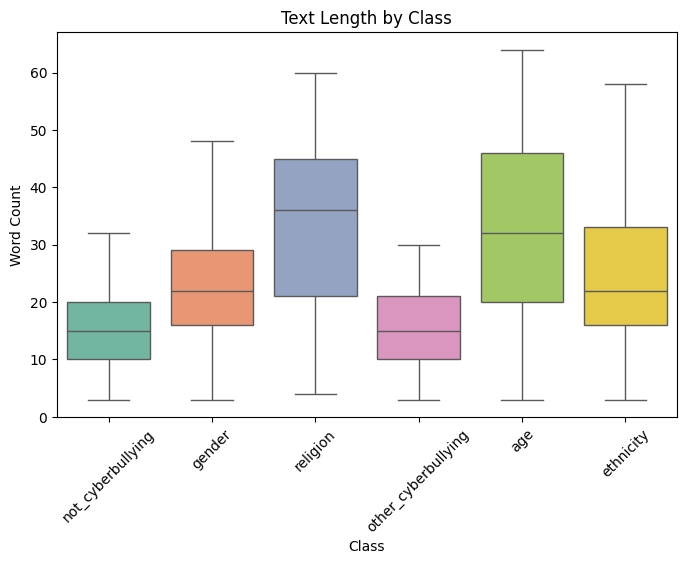

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_raw,
    x="cyberbullying_type",
    y="text_len",
    palette="Set2",
    showfliers=False
)

plt.xticks(rotation=45)
plt.title("Text Length by Class")
plt.xlabel("Class")
plt.ylabel("Word Count")

# salva immagine
plt.savefig(OUTPUT_DIR / "text_length_by_class_boxplot.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:


stop_words = set(stopwords.words("english"))

stop_count = sum(word in stop_words for word in all_words)
print("Stopword ratio:", stop_count / len(all_words))

Stopword ratio: 0.4058810226457343


In [ ]:


vectorizer = CountVectorizer(ngram_range=(2,2), max_features=20)

X = vectorizer.fit_transform(df_raw["tweet_text"])

print(vectorizer.get_feature_names_out())

['all the' 'ass nigger' 'bullied me' 'dumb ass' 'high school' 'http co'
 'if you' 'in high' 'in the' 'islamic terrorism' 'me in' 'of the' 'on the'
 'rape jokes' 'this is' 'to be' 'to the' 'who bullied' 'you are' 'you re']


In [ ]:


bigram_counts = X.sum(axis=0).A1
bigram_names = vectorizer.get_feature_names_out()
bigram_freq = pd.DataFrame({
    'bigram': bigram_names,
    'count': bigram_counts
})
bigram_freq = bigram_freq.sort_values(by='count', ascending=False).head(20)


plt.figure(figsize=(10,6))
sns.barplot(
    data=bigram_freq,
    x="count",
    y="bigram",
    palette="viridis"
)

plt.title("Top 20 Most Frequent Bigrams")
plt.xlabel("Frequency")
plt.ylabel("Bigram")

plt.savefig(OUTPUT_DIR / "top20_bigrams.png", dpi=300, bbox_inches="tight")


plt.close()

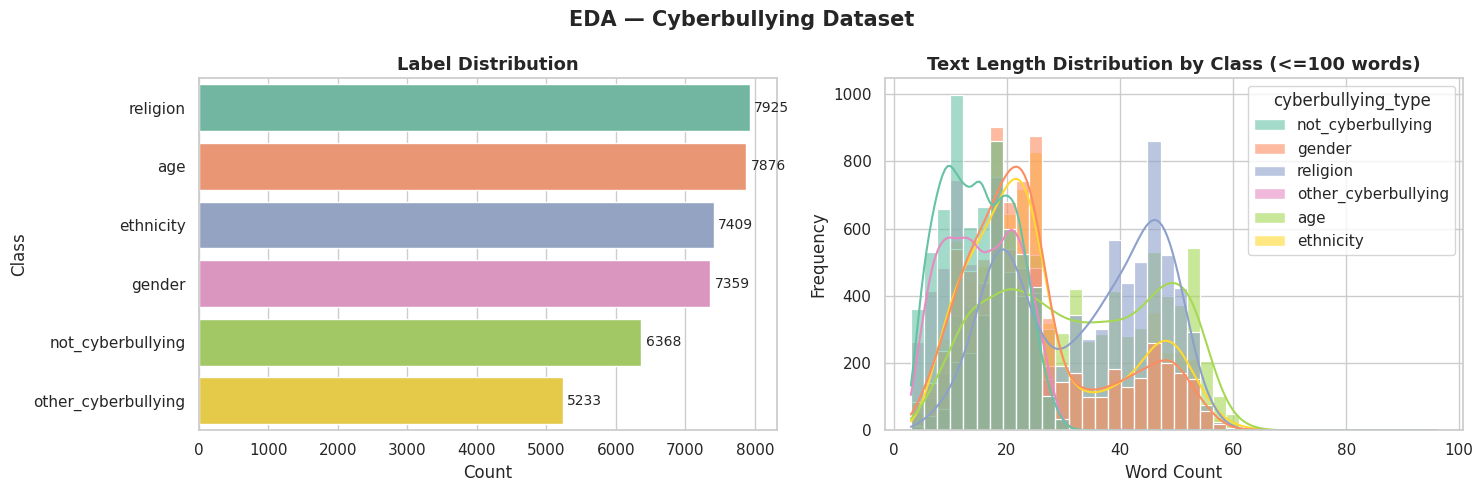

In [ ]:
# text len
df_raw['text_len'] = df_raw['tweet_text'].str.split().apply(len)

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

order = df_raw["cyberbullying_type"].value_counts().index


sns.countplot(
    data=df_raw,
    y="cyberbullying_type",
    order=order,
    palette="Set2",
    ax=axes[0]
)

axes[0].set_title("Label Distribution", fontsize=13, weight="bold")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Class")

for container in axes[0].containers:
    axes[0].bar_label(container, padding=3, fontsize=10)


sns.histplot(
    data=df_raw[df_raw['text_len'] <= 100],
    x="text_len",
    hue="cyberbullying_type",
    bins=40,
    kde=True,
    palette="Set2",
    alpha=0.6,
    ax=axes[1]
)

axes[1].set_title("Text Length Distribution by Class (<=100 words)", fontsize=13, weight="bold")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")

plt.suptitle("EDA — Cyberbullying Dataset", fontsize=15, weight="bold")
plt.tight_layout()


plt.savefig(OUTPUT_DIR / "eda_class_distribution_text_length.png", dpi=300, bbox_inches="tight")

plt.show()

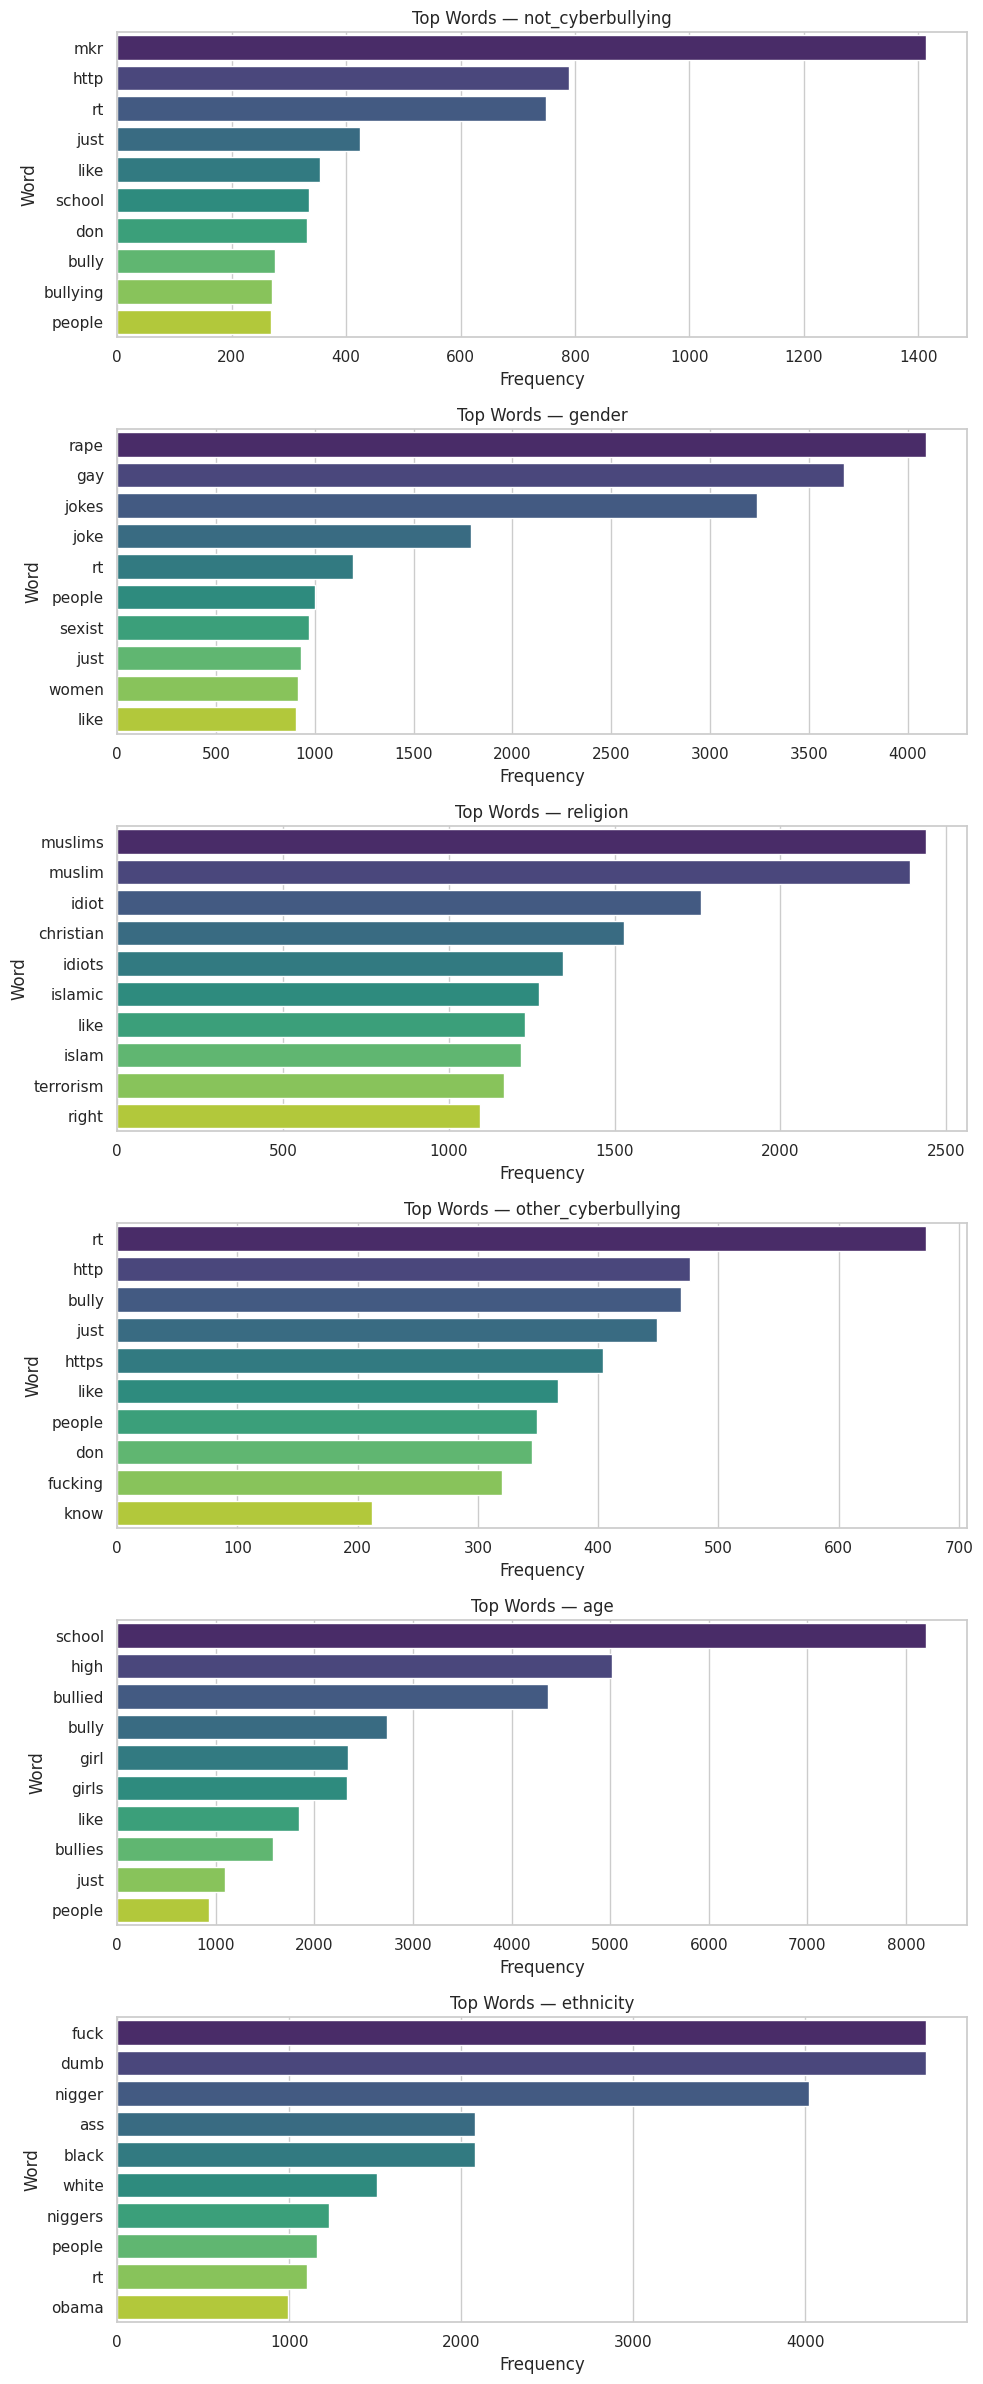

In [ ]:

vectorizer = CountVectorizer(
    stop_words="english",
    max_features=1000
)

X = vectorizer.fit_transform(df_raw["tweet_text"])
words = vectorizer.get_feature_names_out()

word_counts = pd.DataFrame(
    X.toarray(),
    columns=words
)

word_counts["label"] = df_raw["cyberbullying_type"].values

classes = word_counts["label"].unique()

fig, axes = plt.subplots(len(classes), 1, figsize=(10, 4*len(classes)))

for i, label in enumerate(classes):

    subset = word_counts[word_counts["label"] == label]

    top_words = (
        subset.drop(columns="label")
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    sns.barplot(
        x=top_words.values,
        y=top_words.index,
        ax=axes[i],
        palette="viridis"
    )

    axes[i].set_title(f"Top Words — {label}")
    axes[i].set_xlabel("Frequency")
    axes[i].set_ylabel("Word")

plt.tight_layout()


plt.savefig(OUTPUT_DIR / "top_words_per_class.png", dpi=300, bbox_inches="tight")

plt.show()

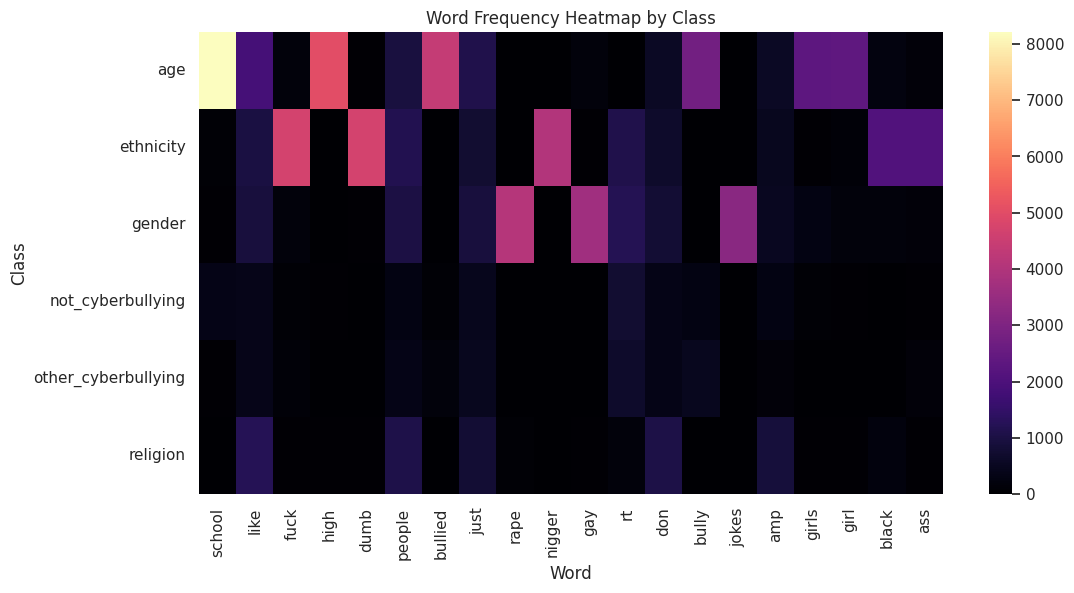

In [ ]:
top_matrix = word_counts.groupby("label").sum()

top_matrix = top_matrix.loc[:, top_matrix.sum().sort_values(ascending=False)[:20].index]

plt.figure(figsize=(12,6))

sns.heatmap(
    top_matrix,
    cmap="magma"
)

plt.title("Word Frequency Heatmap by Class")
plt.xlabel("Word")
plt.ylabel("Class")


plt.savefig(OUTPUT_DIR / "word_frequency_heatmap_by_class.png", dpi=300, bbox_inches="tight")

plt.show()

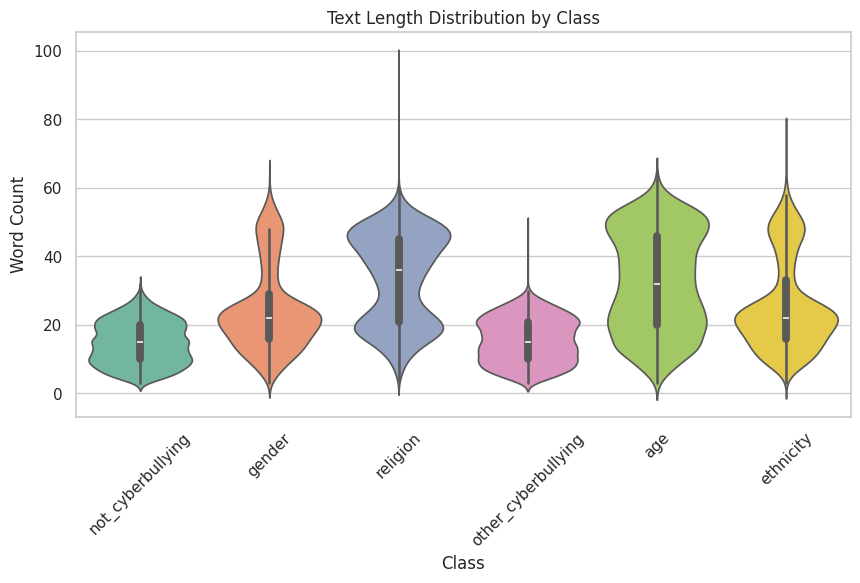

In [ ]:
plt.figure(figsize=(10,5))

sns.violinplot(
    data=df_raw[df_raw["text_len"] <= 100],
    x="cyberbullying_type",
    y="text_len",
    palette="Set2"
)

plt.xticks(rotation=45)
plt.title("Text Length Distribution by Class")
plt.xlabel("Class")
plt.ylabel("Word Count")

# salva figura
plt.savefig(OUTPUT_DIR / "text_length_violinplot_by_class.png", dpi=300, bbox_inches="tight")

plt.show()

# Section 7: Oversampling and loading

In [ ]:
# oversampling only on train
# Original non-oversampled data from df_train
# Make copies to ensure we're working with the initial split, not already modified global variables
X_train_initial_clean = df_train["text_clean"].values.copy()
X_train_initial_raw = df_train["text_raw"].values.copy()
y_train_initial = df_train["label_enc"].values.copy()

classes = np.unique(y_train_initial)
sampling_dict = {cls: 8000 for cls in classes}


ros = RandomOverSampler(sampling_strategy=sampling_dict, random_state=42)

# Oversample the indices to apply the same sampling strategy to all related arrays
original_indices = np.arange(len(y_train_initial)).reshape(-1, 1)

# Fit and resample on these indices and the labels.
# The X_res will contain the oversampled indices.
indices_resampled, y_res = ros.fit_resample(original_indices, y_train_initial)

# Now use these resampled indices to create the new X_train, X_train_raw, and y_train
X_train = X_train_initial_clean[indices_resampled.flatten()]
X_train_raw = X_train_initial_raw[indices_resampled.flatten()]
y_train = y_res

print(f"Oversampled X_train length: {len(X_train)}")
print(f"Oversampled X_train_raw length: {len(X_train_raw)}")
print(f"Oversampled y_train length: {len(y_train)}")

Oversampled X_train length: 40000
Oversampled X_train_raw length: 40000
Oversampled y_train length: 40000


#Section 8: Baseline model

In [ ]:
# ── 5.1 Majority Class Baseline ───────────────────────────────────────────────
dummy = DummyClassifier(strategy="most_frequent", random_state=CFG["seed"])
dummy.fit(X_train, y_train)
dummy_preds = dummy.predict(X_test)

evaluate_clf("Majority Baseline", y_test, dummy_preds, label_encoder=le)


  Majority Baseline | TEST
  Accuracy      : 0.2133
  F1 (macro)    : 0.0703
  F1 (weighted) : 0.0750

                   precision    recall  f1-score   support

              age       0.21      1.00      0.35      1182
        ethnicity       0.00      0.00      0.00      1111
           gender       0.00      0.00      0.00      1104
not_cyberbullying       0.00      0.00      0.00       955
         religion       0.00      0.00      0.00      1189

         accuracy                           0.21      5541
        macro avg       0.04      0.20      0.07      5541
     weighted avg       0.05      0.21      0.08      5541



{'accuracy': 0.21331889550622632,
 'f1_macro': 0.07032574743418117,
 'f1_weighted': 0.07500905384154678}

# Section 9: TF-IDF + Logistic Regression

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

def build_tfidf(word_ngrams=(1, 2), char_ngrams=True, max_features=30000):
    word_vec = TfidfVectorizer(
        analyzer="word",
        ngram_range=word_ngrams,
        max_features=max_features,
        sublinear_tf=True,
        min_df=3,
        max_df=0.95
    )

    X_tr_w = word_vec.fit_transform(X_train)
    X_va_w = word_vec.transform(X_val)
    X_te_w = word_vec.transform(X_test)

    print("Word features:", X_tr_w.shape[1])

    if char_ngrams:
        char_vec = TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            max_features=10000,
            sublinear_tf=True,
            min_df=3
        )

        X_tr_c = char_vec.fit_transform(X_train)
        X_va_c = char_vec.transform(X_val)
        X_te_c = char_vec.transform(X_test)

        print("Char features:", X_tr_c.shape[1])

        X_tr = hstack([X_tr_w, X_tr_c])
        X_va = hstack([X_va_w, X_va_c])
        X_te = hstack([X_te_w, X_te_c])

        print("Total features:", X_tr.shape[1])

        return X_tr, X_va, X_te, (word_vec, char_vec)

    print("Total features:", X_tr_w.shape[1])
    return X_tr_w, X_va_w, X_te_w, (word_vec,)

In [ ]:
X_tr_tfidf, X_va_tfidf, X_te_tfidf, tfidf_vecs = build_tfidf(
    word_ngrams=CFG["tfidf_word_ngrams"],
    char_ngrams=CFG["use_char_ngrams"]
)

print(f"TF-IDF feature dim: {X_tr_tfidf.shape[1]:,}")

Word features: 30000
Char features: 10000
Total features: 40000
TF-IDF feature dim: 40,000


In [ ]:
!grep -n "CFG\|import" /content/mago/utils/plots.py | head -20

2:from __future__ import annotations
4:from pathlib import Path
5:import re
7:import matplotlib.pyplot as plt
8:import matplotlib.ticker as mticker
9:import numpy as np
10:import pandas as pd
11:import seaborn as sns
12:from IPython.display import display
13:from sklearn.metrics import confusion_matrix
15:from .data import slugify
16:from .metrics import get_top_models_df
18:CFG: dict = {}
53:    out_path = CFG['output_paths']['plots_comparison'] / f"comparison_{metric}_{split}.png"
79:    out_path = CFG['output_paths']['plots_comparison'] / f"comparison_top{top_n}_{metric}_{split}.png"
99:    fname = CFG["output_paths"]["plots_confusion"] / f"cm_{slugify(model_name)}.png"
147:    fname = CFG["output_paths"]["plots_history"] / f"history_{slugify(model_name)}.png"
325:    plot_root = CFG["output_dir"] / "cross_dataset_eval" / "plots"


[LogReg CV] F1-macro: 0.9556 ± 0.0014

  TF-IDF + LogReg | VAL
  Accuracy      : 0.9240
  F1 (macro)    : 0.9207
  F1 (weighted) : 0.9248

                   precision    recall  f1-score   support

              age       0.97      0.98      0.98      1181
        ethnicity       0.98      0.99      0.98      1112
           gender       0.93      0.84      0.88      1104
not_cyberbullying       0.77      0.87      0.81       955
         religion       0.96      0.94      0.95      1189

         accuracy                           0.92      5541
        macro avg       0.92      0.92      0.92      5541
     weighted avg       0.93      0.92      0.92      5541


  TF-IDF + LogReg | TEST
  Accuracy      : 0.9284
  F1 (macro)    : 0.9246
  F1 (weighted) : 0.9288

                   precision    recall  f1-score   support

              age       0.96      0.98      0.97      1182
        ethnicity       0.99      0.99      0.99      1111
           gender       0.93      0.86      0.9

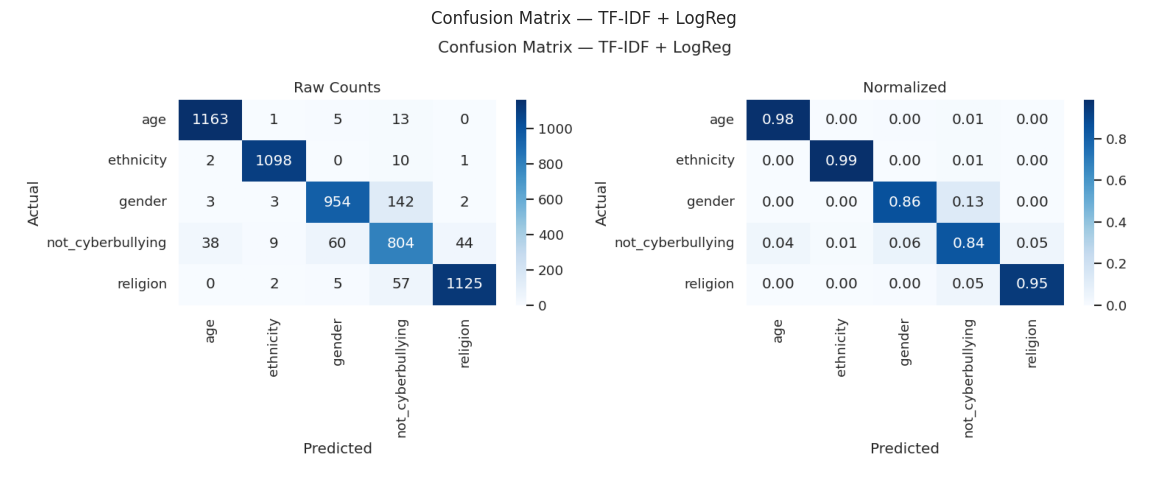

Displayed existing confusion matrix: outputs/cm_tf_idf_logreg.png


['models/logreg.pkl']

In [ ]:
# ── 5.3 TF-IDF + Logistic Regression ─────────────────────────────────────────

# Restore missing class_weight and cross-validation configuration parameters from the original CFG
# These values were overwritten by a previous cell's CFG redefinition.
# Assuming original values from global config (cell -Ht-1nLAqoRl).
CFG["class_weight"] = "balanced"
CFG["use_cv"] = True
CFG["cv_folds"] = 5
# Restore Path objects for directories
CFG["output_dir"] = Path("outputs/")
CFG["model_dir"] = Path("models/")
CFG["output_paths"] = {
    "plots_comparison": Path("outputs/"),
    "plots_confusion":  Path("outputs/"),
    "plots_history":    Path("outputs/"),
    "metrics":          Path("outputs/"), # Re-added this line to fix KeyError
}

logreg = LogisticRegression(
    max_iter=1000, C=1.0,
    class_weight=CFG["class_weight"],
    solver="saga",
    random_state=CFG["seed"]
)

if CFG["use_cv"]:
    cv_scores = cross_val_score(
        logreg, X_tr_tfidf, y_train,
        cv=cv, scoring="f1_macro", n_jobs=-1
    )
    print(f"[LogReg CV] F1-macro: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

logreg.fit(X_tr_tfidf, y_train)

evaluate_clf("TF-IDF + LogReg", y_val,
             logreg.predict(X_va_tfidf), label_encoder=le, split="val")
evaluate_clf("TF-IDF + LogReg", y_test,
             logreg.predict(X_te_tfidf),
             logreg.predict_proba(X_te_tfidf), label_encoder=le)
plot_confusion_matrix_clf(y_test, logreg.predict(X_te_tfidf), "TF-IDF + LogReg", le)
# ── salva immagine della confusion matrix ──
import matplotlib.pyplot as plt

# salva l'ultima figura generata da plot_confusion_matrix_clf()
plt.savefig(OUTPUT_DIR / "confusion_matrix_logreg.png", dpi=300, bbox_inches="tight")
plt.close()  # chiude la figura per liberare memoria
joblib.dump(logreg, CFG["model_dir"] / "logreg.pkl")

In [ ]:


model_path = Path("models/logreg.pkl")
print(model_path.resolve())

/content/models/logreg.pkl


In [ ]:
!ls -l models/

total 1564
-rw-r--r-- 1 root root 1600943 Mar 16 13:31 logreg.pkl


In [ ]:


model_path = Path("models/logreg.pkl")
print(model_path.resolve())

/content/models/logreg.pkl


In [ ]:
######## MODELLO SU DRIVE

local_model_path = Path("models/logreg.pkl")

drive_model_dir = Path("/content/drive/MyDrive/models")


shutil.copy(local_model_path, drive_model_dir)
print(f"Modello copiato su Drive: {drive_model_dir / 'logreg.pkl'}")

Modello copiato su Drive: /content/drive/MyDrive/models/logreg.pkl


In [ ]:

!pip install --upgrade xgboost --quiet

In [ ]:
import torch
torch.cuda.is_available()

True

In [ ]:
import xgboost
print(xgboost.__version__)

3.2.0


# Section 10: TF-IDF + XGBoost

[0]	validation_0-mlogloss:1.42025
[1]	validation_0-mlogloss:1.27177
[2]	validation_0-mlogloss:1.15116
[3]	validation_0-mlogloss:1.05056
[4]	validation_0-mlogloss:0.96589
[5]	validation_0-mlogloss:0.89092
[6]	validation_0-mlogloss:0.82630
[7]	validation_0-mlogloss:0.77013
[8]	validation_0-mlogloss:0.71895
[9]	validation_0-mlogloss:0.67380
[10]	validation_0-mlogloss:0.63375
[11]	validation_0-mlogloss:0.59860
[12]	validation_0-mlogloss:0.56628
[13]	validation_0-mlogloss:0.53740
[14]	validation_0-mlogloss:0.51123
[15]	validation_0-mlogloss:0.48757
[16]	validation_0-mlogloss:0.46599
[17]	validation_0-mlogloss:0.44641
[18]	validation_0-mlogloss:0.42834
[19]	validation_0-mlogloss:0.41231
[20]	validation_0-mlogloss:0.39739
[21]	validation_0-mlogloss:0.38363
[22]	validation_0-mlogloss:0.37170
[23]	validation_0-mlogloss:0.36030
[24]	validation_0-mlogloss:0.34968
[25]	validation_0-mlogloss:0.33966
[26]	validation_0-mlogloss:0.33050
[27]	validation_0-mlogloss:0.32223
[28]	validation_0-mlogloss:0.3

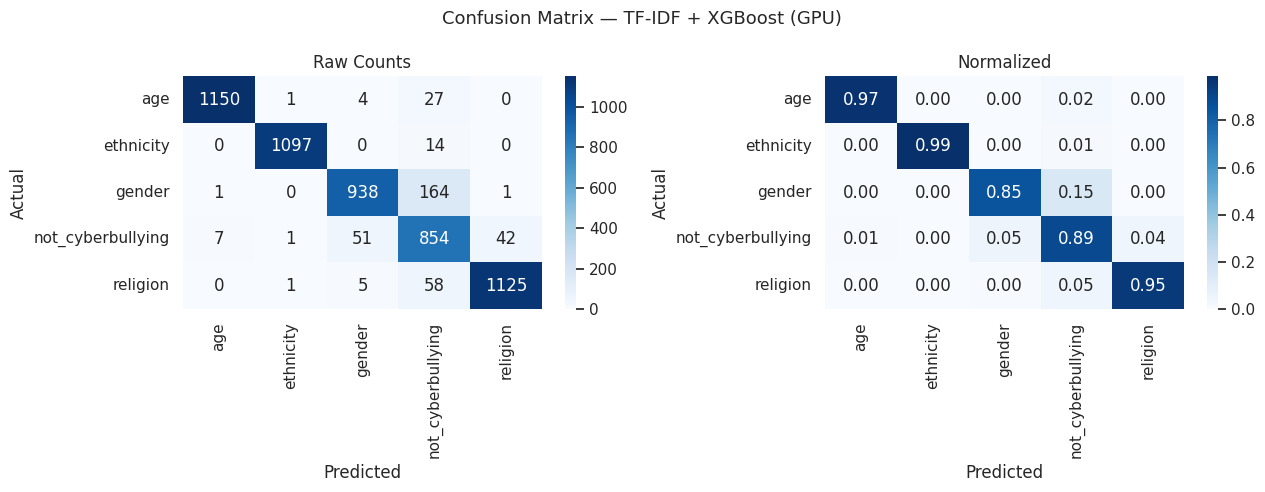

['models/xgboost_gpu.pkl']

In [ ]:
# ── 5.4 TF-IDF + XGBoost (GPU Ready, no CV) ─────────────────────────────
xgb = XGBClassifier(
    n_estimators=250,           # massimo numero di alberi
    max_depth=6,                # profondità massima
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",     # Changed from "gpu_hist" to "hist" for compatibility
    eval_metric="mlogloss",
    random_state=CFG["seed"],
    verbosity=1
)

# Fit finale
xgb.fit(
    X_tr_tfidf, y_train,
    eval_set=[(X_va_tfidf, y_val)],
    # early_stopping_rounds=20,
    verbose=True
)


xgb_val_preds = xgb.predict(X_va_tfidf)
xgb_test_preds = xgb.predict(X_te_tfidf)

#  plot confusion matrix
evaluate_clf("TF-IDF + XGBoost (GPU)", y_val, xgb_val_preds, label_encoder=le, split="val")
evaluate_clf("TF-IDF + XGBoost (GPU)", y_test, xgb_test_preds, xgb.predict_proba(X_te_tfidf), label_encoder=le)
plot_confusion_matrix_clf(y_test, xgb_test_preds, "TF-IDF + XGBoost (GPU)", le)

joblib.dump(xgb, CFG["model_dir"] / "xgboost_gpu.pkl")

In [ ]:


local_model_path = Path("models/xgboost_gpu.pkl")


drive_model_dir = Path("/content/drive/MyDrive/models")


shutil.copy(local_model_path, drive_model_dir)
print(f"Modello copiato su Drive: {drive_model_dir / 'xgboost_gpu.pkl'}")

Modello copiato su Drive: /content/drive/MyDrive/models/xgboost_gpu.pkl


# Section 11: Utilities

In [ ]:


drive_model_dir = Path("/content/drive/MyDrive/models")

xgb = joblib.load(drive_model_dir / "xgboost_gpu.pkl")

In [ ]:
!grep -rn "def build_vocab" /content/mago/utils/

/content/mago/utils/data.py:348:def build_vocab(


In [ ]:
# ── 6.1 Vocabulary Builder ────────────────────────────────────────────────────

CFG["vocab_size"] = 30_000
CFG["pad_token"] = "<PAD>"
CFG["unk_token"] = "<UNK>"


vocab = build_vocab(
    X_train,
    max_vocab=CFG["vocab_size"],
    pad_token=CFG["pad_token"],
    unk_token=CFG["unk_token"]
)
print(f"Vocabulary size: {len(vocab):,}")

Vocabulary size: 28,732


In [ ]:
# ── 6.2 Embedding Matrix ──────────────────────────────────────────────────────

CFG["embedding_model"] = "glove-wiki-gigaword-100" # or "fasttext-wiki-news-subwords-300"
CFG["embedding_dim"] = 100

embedding_matrix = load_embedding_matrix(
    vocab, CFG["embedding_model"], CFG["embedding_dim"]
)
print(f"Embedding matrix shape: {embedding_matrix.shape}")

Loading glove-wiki-gigaword-100 ...
[==================================================] 100.0% 128.1/128.1MB downloaded
Coverage: 49.6%  (hits=14249, misses=14483)
Embedding matrix shape: (28732, 100)


In [ ]:
!grep -rn "def texts_to_sequences" /content/mago/utils/

/content/mago/utils/data.py:403:def texts_to_sequences(texts, vocab: dict, max_len: int,


In [ ]:
# ── 6.3 Text → Padded Token-ID Sequences ─────────────────────────────────────


CFG["max_seq_len"] = 128

seq_train = texts_to_sequences(X_train, vocab, CFG["max_seq_len"])
seq_val   = texts_to_sequences(X_val,   vocab, CFG["max_seq_len"])
seq_test  = texts_to_sequences(X_test,  vocab, CFG["max_seq_len"])

print(f"seq_train: {seq_train.shape} | seq_val: {seq_val.shape} | seq_test: {seq_test.shape}")

seq_train: (40000, 128) | seq_val: (5541, 128) | seq_test: (5541, 128)


In [ ]:
# ── 6.4 PyTorch Dataset & DataLoaders ────────────────────────────────────────
CFG["dl_batch_size"] = 64

loader_train, loader_val, loader_test = make_loaders(
    seq_train, y_train, seq_val, y_val, seq_test, y_test,
    batch_size=CFG["dl_batch_size"]
)
print("DataLoaders ready.")

DataLoaders ready.


In [ ]:
!grep -n "COLORS" /content/mago/utils/plots.py | head -10

19:COLORS: list = []
158:    axes[0].plot(history["train_loss"], label="Train", marker="o", color=COLORS[0])
159:    axes[0].plot(history["val_loss"], label="Val", marker="o", color=COLORS[2])
164:    axes[1].plot(history["val_f1_macro"], marker="o", color=COLORS[1])
205:    if len(models) <= 5 and "COLORS" in globals() and len(COLORS) >= len(models):
206:        palette = COLORS[: len(models)]
359:        "deep": COLORS[1],
418:        ["#F7FAFC", "#D9EAF7", COLORS[2], COLORS[1], COLORS[0]],


# Section 12: Text CNN


MLP params: 2,900,341
Resumed from models/glove_mlp/checkpoints/last.pt (epoch=5, best_f1=0.8863)
Epoch   6/20 | tr_loss=0.0196 | va_loss=0.4717 | val_f1=0.8733 | 0.7s
Early stopping triggered at epoch 6.
Restored best checkpoint | val_f1=0.8863 | path=models/glove_mlp/checkpoints/best.pt
Training complete.


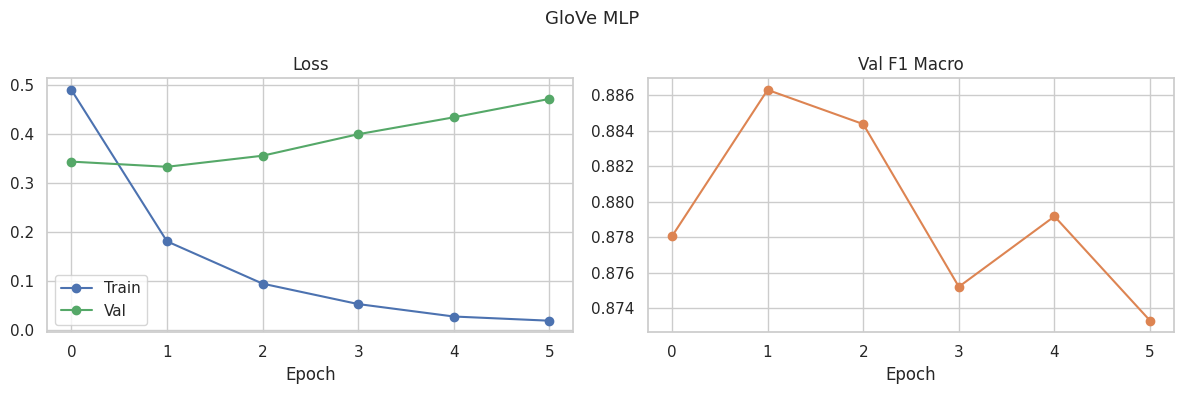


  GloVe MLP | TEST
  Accuracy      : 0.8950
  F1 (macro)    : 0.8875
  F1 (weighted) : 0.8936

                   precision    recall  f1-score   support

              age       0.95      0.96      0.95      1182
        ethnicity       0.96      0.96      0.96      1111
           gender       0.88      0.86      0.87      1104
not_cyberbullying       0.75      0.70      0.72       955
         religion       0.91      0.96      0.93      1189

         accuracy                           0.89      5541
        macro avg       0.89      0.89      0.89      5541
     weighted avg       0.89      0.89      0.89      5541



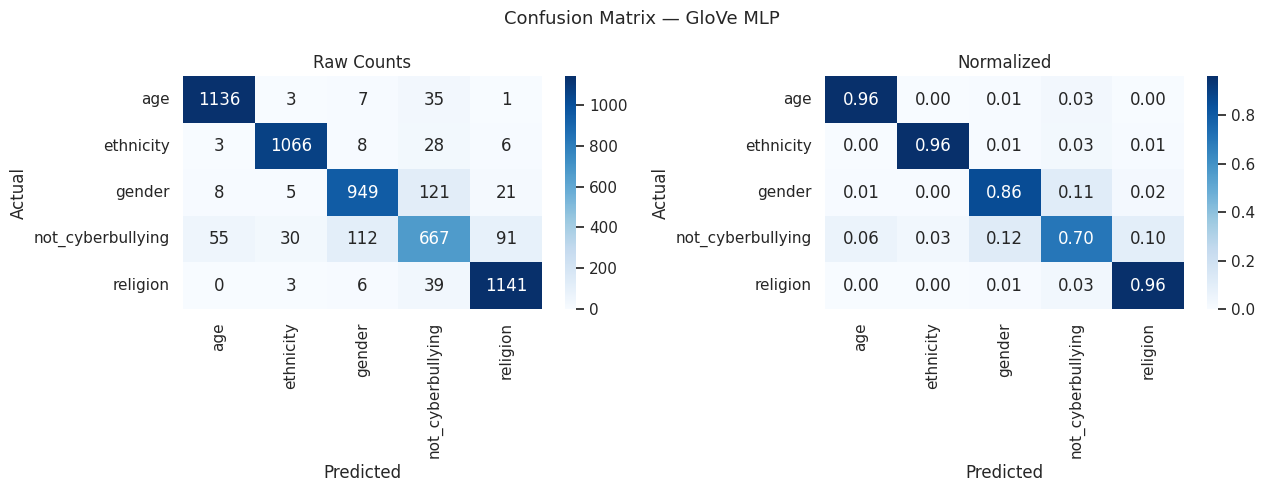

In [ ]:
CFG["num_labels"] = len(le.classes_)
CFG["dropout"] = 0.3
CFG["dl_epochs"] = 20
CFG["dl_lr"] = 1e-3
CFG["dl_patience"] = 3
CFG["device"] = (
    "mps"  if torch.backends.mps.is_available() and torch.backends.mps.is_built()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
# Restore Path objects for directories
CFG["output_dir"] = Path("outputs/")
CFG["model_dir"] = Path("models/")
CFG["log_dir"] = Path("logs/")

set_seed(CFG["seed"])
mlp_model = EmbeddingMLP(
    embedding_matrix=embedding_matrix,
    num_classes=CFG["num_labels"],
    hidden_dim=256,
    dropout=CFG["dropout"]
)
print(f"MLP params: {sum(p.numel() for p in mlp_model.parameters()):,}")

mlp_history = train_model(
    mlp_model, loader_train, loader_val,
    model_name="GloVe MLP",
    epochs=CFG["dl_epochs"], lr=CFG["dl_lr"],
    patience=CFG["dl_patience"], device=CFG["device"]
)
plot_history(mlp_history, "GloVe MLP")

mlp_preds = predict(mlp_model, loader_test, CFG["device"])
evaluate_clf("GloVe MLP", y_test, mlp_preds, label_encoder=le)
plot_confusion_matrix_clf(y_test, mlp_preds, "GloVe MLP", le)

In [ ]:


local_model_path = Path("models/mlp.pth")

torch.save(mlp_model.state_dict(), local_model_path)
print(f"MLP salvato localmente: {local_model_path}")

drive_model_dir = Path("/content/drive/MyDrive/models")

shutil.copy(local_model_path, drive_model_dir)
print(f"MLP copiato su Drive: {drive_model_dir / 'mlp.pth'}")

MLP salvato localmente: models/mlp.pth
MLP copiato su Drive: /content/drive/MyDrive/models/mlp.pth


In [ ]:
ckpt = torch.load(drive_model_dir / "mlp.pth", map_location=CFG["device"])
target_size = ckpt["embedding.weight"].shape[0]

current_size = embedding_matrix.shape[0]
if current_size < target_size:
    padding = np.zeros((target_size - current_size, embedding_matrix.shape[1]), dtype=np.float32)
    embedding_matrix_padded = np.vstack([embedding_matrix, padding])
elif current_size > target_size:
    embedding_matrix_padded = embedding_matrix[:target_size]
else:
    embedding_matrix_padded = embedding_matrix

mlp_model = EmbeddingMLP(
    embedding_matrix=embedding_matrix_padded,
    num_classes=CFG["num_labels"],
    hidden_dim=256,
    dropout=CFG["dropout"]
)

mlp_model.load_state_dict(ckpt)
mlp_model.to(CFG["device"])
mlp_model.eval()

EmbeddingMLP(
  (embedding): Embedding(28732, 100, padding_idx=0)
  (fc): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=5, bias=True)
  )
)

# Section 13: BiLSTM + Attention

BiLSTM params: 3,505,525
Epoch   1/20 | tr_loss=0.1931 | va_loss=0.2856 | val_f1=0.8985 | 3.0s ✓  <-- new best
Epoch   2/20 | tr_loss=0.0869 | va_loss=0.3128 | val_f1=0.8996 | 2.8s ✓  <-- new best
Epoch   3/20 | tr_loss=0.0622 | va_loss=0.3450 | val_f1=0.8937 | 2.8s
Epoch   4/20 | tr_loss=0.0471 | va_loss=0.3628 | val_f1=0.8913 | 2.8s
Epoch   5/20 | tr_loss=0.0311 | va_loss=0.3953 | val_f1=0.8955 | 2.8s
Early stopping triggered at epoch 5.
Restored best checkpoint | val_f1=0.8996 | path=models/glove_bilstm_att/checkpoints/best.pt
Training complete.


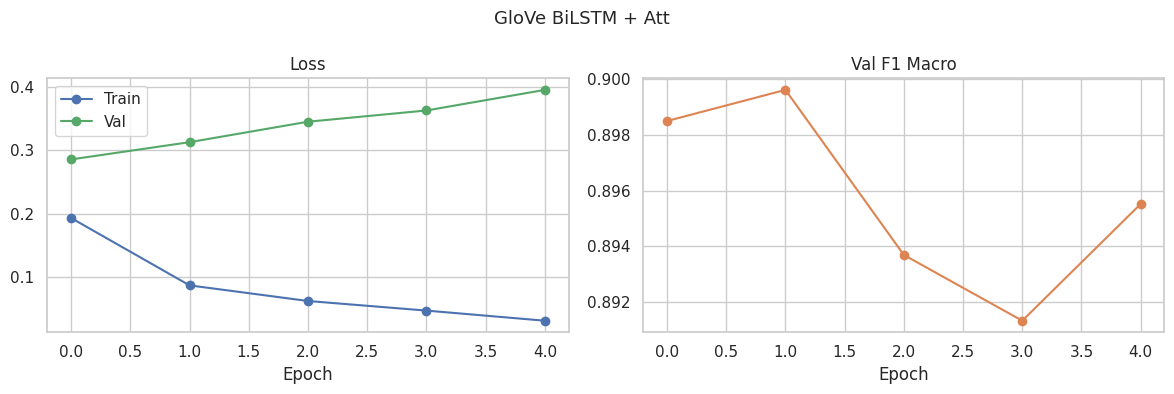


  GloVe BiLSTM + Att | TEST
  Accuracy      : 0.9058
  F1 (macro)    : 0.8987
  F1 (weighted) : 0.9042

                   precision    recall  f1-score   support

              age       0.94      0.98      0.96      1182
        ethnicity       0.96      0.98      0.97      1111
           gender       0.90      0.85      0.87      1104
not_cyberbullying       0.78      0.73      0.75       955
         religion       0.93      0.95      0.94      1189

         accuracy                           0.91      5541
        macro avg       0.90      0.90      0.90      5541
     weighted avg       0.90      0.91      0.90      5541



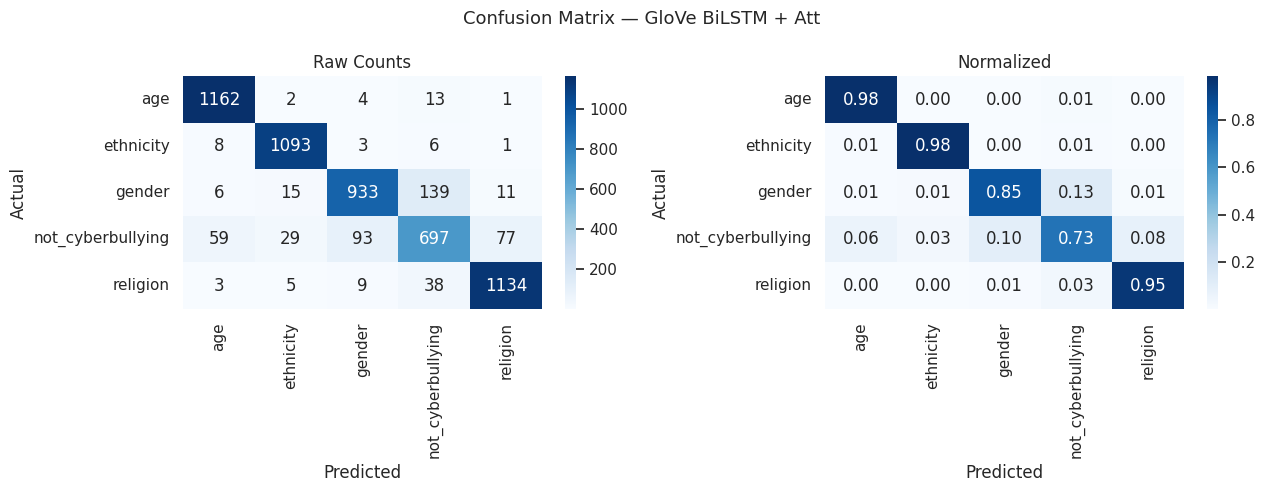

In [ ]:
# ── 9.3 Train BiLSTM + Attention ──────────────────────────────────────────────

CFG["lstm_hidden_dim"] = 128
CFG["lstm_num_layers"] = 2
CFG["dropout"] = 0.3
CFG["dl_epochs"] = 20
CFG["dl_lr"] = 1e-3
CFG["dl_patience"] = 3
CFG["device"] = (
    "mps"  if torch.backends.mps.is_available() and torch.backends.mps.is_built()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
# Restore Path objects for directories
CFG["output_dir"] = Path("outputs/")
CFG["model_dir"] = Path("models/")
CFG["log_dir"] = Path("logs/")

set_seed(CFG["seed"])

atentos_model = BiLSTMAttention(
    embedding_matrix=embedding_matrix,
    num_classes=CFG["num_labels"],
    hidden_dim=CFG["lstm_hidden_dim"],
    num_layers=CFG["lstm_num_layers"],
    dropout=CFG["dropout"]
)
print(f"BiLSTM params: {sum(p.numel() for p in atentos_model.parameters()):,}")

att_history = train_model(
    atentos_model, loader_train, loader_val,
    model_name="GloVe BiLSTM + Att",
    epochs=CFG["dl_epochs"], lr=CFG["dl_lr"],
    patience=CFG["dl_patience"], device=CFG["device"]
)
plot_history(att_history, "GloVe BiLSTM + Att")

att_preds = predict(atentos_model, loader_test, CFG["device"])
evaluate_clf("GloVe BiLSTM + Att", y_test, att_preds, label_encoder=le)
plot_confusion_matrix_clf(y_test, att_preds, "GloVe BiLSTM + Att", le)

In [ ]:

drive_model_dir = Path("/content/drive/MyDrive/models")
drive_model_dir.mkdir(exist_ok=True)
torch.save(atentos_model, drive_model_dir / "bilstm_attention_full.pth")

# Section 14: GloVe CNN

TextCNN params: 2,990,709
Epoch   1/20 | tr_loss=0.1807 | va_loss=0.2990 | val_f1=0.8964 | 1.4s ✓  <-- new best
Epoch   2/20 | tr_loss=0.0602 | va_loss=0.3397 | val_f1=0.8919 | 0.9s
Epoch   3/20 | tr_loss=0.0290 | va_loss=0.3916 | val_f1=0.8907 | 0.9s
Epoch   4/20 | tr_loss=0.0131 | va_loss=0.4275 | val_f1=0.8910 | 0.9s
Early stopping triggered at epoch 4.
Restored best checkpoint | val_f1=0.8964 | path=models/glove_cnn/checkpoints/best.pt
Training complete.


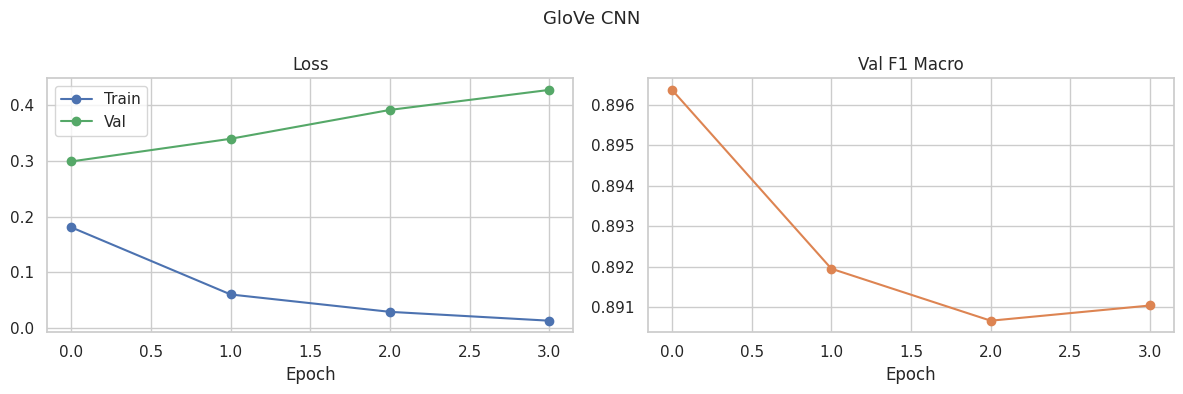


  GloVe CNN | TEST
  Accuracy      : 0.9013
  F1 (macro)    : 0.8917
  F1 (weighted) : 0.8980

                   precision    recall  f1-score   support

              age       0.95      0.98      0.96      1182
        ethnicity       0.96      0.98      0.97      1111
           gender       0.86      0.88      0.87      1104
not_cyberbullying       0.80      0.66      0.72       955
         religion       0.90      0.97      0.93      1189

         accuracy                           0.90      5541
        macro avg       0.89      0.89      0.89      5541
     weighted avg       0.90      0.90      0.90      5541



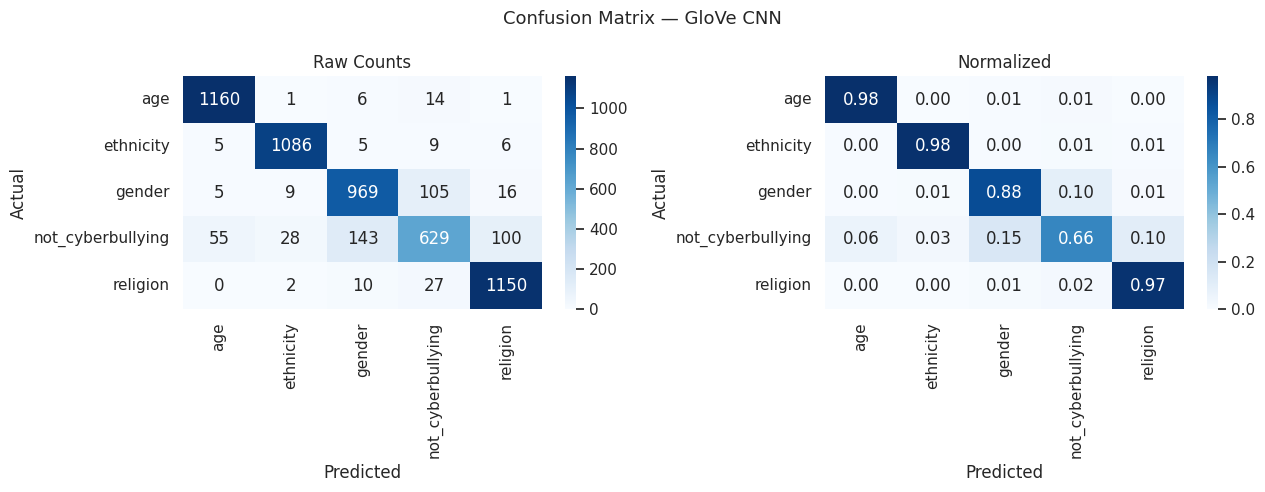

In [ ]:
set_seed(42)

# ── 8.4 Train TextCNN ────────────────────────────────────────────────────────
CFG["cnn_num_filters"] = 128
CFG["cnn_kernel_sizes"] = [2, 3, 4]
CFG["dropout"] = 0.3
CFG["dl_epochs"] = 20
CFG["dl_lr"] = 1e-3
CFG["dl_patience"] = 3
CFG["device"] = (
    "mps"  if torch.backends.mps.is_available() and torch.backends.mps.is_built()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
# Restore Path objects for directories
CFG["output_dir"] = Path("outputs/")
CFG["model_dir"] = Path("models/")
CFG["log_dir"] = Path("logs/")

set_seed(CFG["seed"])
cnn_model = TextCNN(
    embedding_matrix=embedding_matrix,
    num_classes=CFG["num_labels"],
    num_filters=CFG["cnn_num_filters"],
    kernel_sizes=CFG["cnn_kernel_sizes"],
    dropout=CFG["dropout"]
)
print(f"TextCNN params: {sum(p.numel() for p in cnn_model.parameters()):,}")

cnn_history = train_model(
    cnn_model, loader_train, loader_val,
    model_name="GloVe CNN",
    epochs=CFG["dl_epochs"], lr=CFG["dl_lr"],
    patience=CFG["dl_patience"], device=CFG["device"]
)
plot_history(cnn_history, "GloVe CNN")

cnn_preds = predict(cnn_model, loader_test, CFG["device"])
evaluate_clf("GloVe CNN", y_test, cnn_preds, label_encoder=le)
plot_confusion_matrix_clf(y_test, cnn_preds, "GloVe CNN", le)

In [ ]:
# save
drive_model_dir.mkdir(exist_ok=True)
torch.save(cnn_model, drive_model_dir / "textcnn_full.pth")

# Section 15:  GloVe BiLSTM

BiLSTM params: 3,505,525
Epoch   1/20 | tr_loss=0.1931 | va_loss=0.2856 | val_f1=0.8985 | 2.8s ✓  <-- new best
Epoch   2/20 | tr_loss=0.0869 | va_loss=0.3128 | val_f1=0.8996 | 2.8s ✓  <-- new best
Epoch   3/20 | tr_loss=0.0622 | va_loss=0.3450 | val_f1=0.8937 | 2.8s
Epoch   4/20 | tr_loss=0.0471 | va_loss=0.3628 | val_f1=0.8913 | 2.8s
Epoch   5/20 | tr_loss=0.0311 | va_loss=0.3953 | val_f1=0.8955 | 2.8s
Early stopping triggered at epoch 5.
Restored best checkpoint | val_f1=0.8996 | path=models/glove_bilstm/checkpoints/best.pt
Training complete.


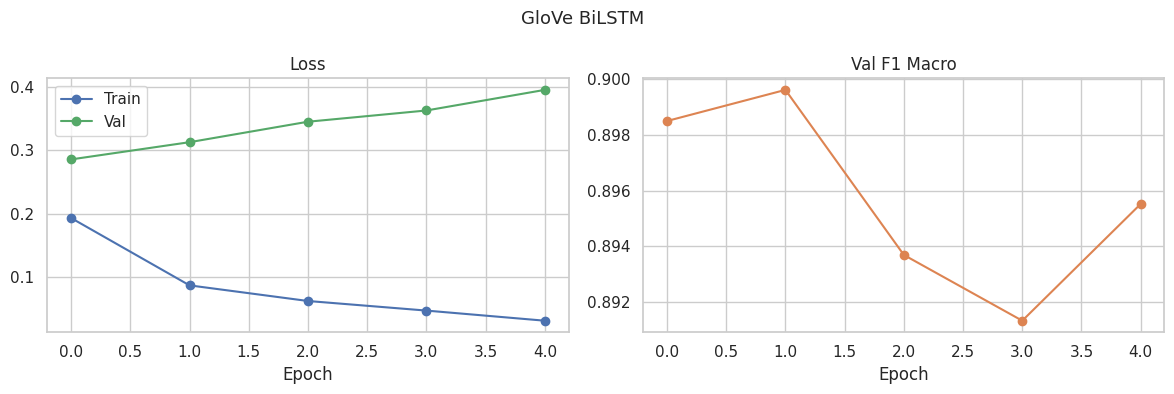


  GloVe BiLSTM | TEST
  Accuracy      : 0.9058
  F1 (macro)    : 0.8987
  F1 (weighted) : 0.9042

                   precision    recall  f1-score   support

              age       0.94      0.98      0.96      1182
        ethnicity       0.96      0.98      0.97      1111
           gender       0.90      0.85      0.87      1104
not_cyberbullying       0.78      0.73      0.75       955
         religion       0.93      0.95      0.94      1189

         accuracy                           0.91      5541
        macro avg       0.90      0.90      0.90      5541
     weighted avg       0.90      0.91      0.90      5541



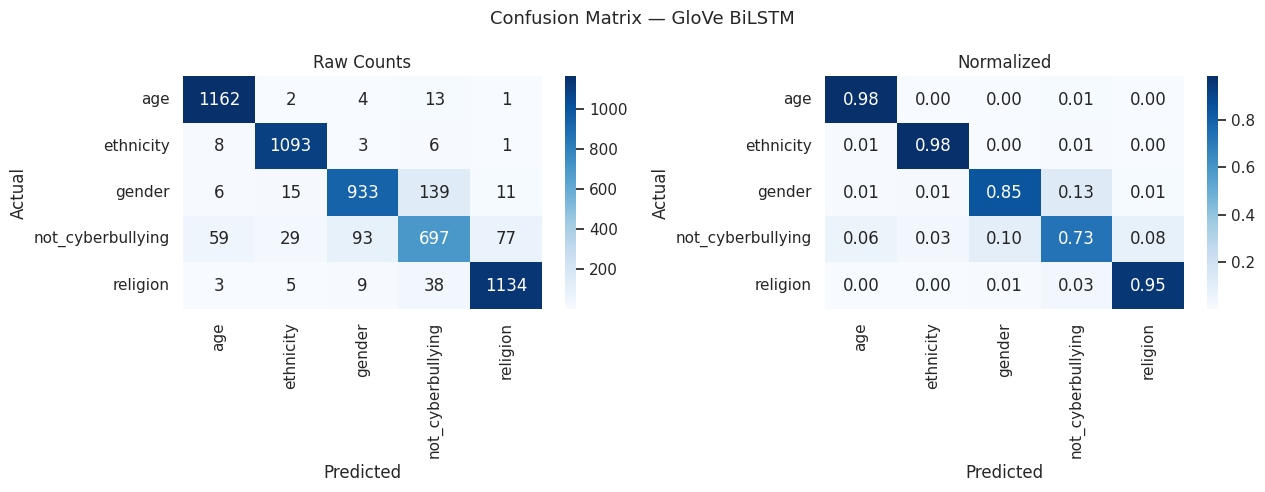

In [ ]:
# ── 9.3 Train BiLSTM ──────────────────────────────────────────────────────────
set_seed(CFG["seed"])
bilstm_model = BiLSTMAttention(
    embedding_matrix=embedding_matrix,
    num_classes=CFG["num_labels"],
    hidden_dim=CFG["lstm_hidden_dim"],
    num_layers=CFG["lstm_num_layers"],
    dropout=CFG["dropout"]
)
print(f"BiLSTM params: {sum(p.numel() for p in bilstm_model.parameters()):,}")

lstm_history = train_model(
    bilstm_model, loader_train, loader_val,
    model_name="GloVe BiLSTM",
    epochs=CFG["dl_epochs"], lr=CFG["dl_lr"],
    patience=CFG["dl_patience"], device=CFG["device"]
)
plot_history(lstm_history, "GloVe BiLSTM")

bilstm_preds = predict(bilstm_model, loader_test, CFG["device"])
evaluate_clf("GloVe BiLSTM", y_test, bilstm_preds, label_encoder=le)
plot_confusion_matrix_clf(y_test, bilstm_preds, "GloVe BiLSTM", le)

In [ ]:
# Save
drive_model_dir.mkdir(exist_ok=True)
torch.save(bilstm_model, drive_model_dir / "bilstm_full.pth")

# Section 16: BERT

In [ ]:
# ── 10.3 Tokeniser & Datasets ─────────────────────────────────────────────────
CFG["trf_model"] = "bert-base-uncased"
CFG["max_len"] = 256

trf_tokenizer = AutoTokenizer.from_pretrained(CFG["trf_model"])

trf_ds_train = HFTextDataset(X_train_raw, y_train, trf_tokenizer, CFG["max_len"])
trf_ds_val   = HFTextDataset(X_val_raw,   y_val,   trf_tokenizer, CFG["max_len"])
trf_ds_test  = HFTextDataset(X_test_raw,  y_test,  trf_tokenizer, CFG["max_len"])

print(f"Train HF dataset: {len(trf_ds_train)} | "
      f"Val: {len(trf_ds_val)} | Test: {len(trf_ds_test)}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train HF dataset: 40000 | Val: 5541 | Test: 5541


In [ ]:
# ── 10.4 Model + Trainer ────────────────────────

CFG["batch_size"] = 16
CFG["epochs"] = 5
CFG["lr"] = 2e-5
# Restore Path objects for directories
CFG["output_dir"] = Path("outputs/")
CFG["model_dir"] = Path("models/")
CFG["log_dir"] = Path("logs/")

out_dir = CFG["model_dir"] / "transformer"
out_dir.mkdir(parents=True, exist_ok=True)

trf_model = AutoModelForSequenceClassification.from_pretrained(
    CFG["trf_model"],
    num_labels=CFG["num_labels"],
    problem_type="single_label_classification",
    from_tf=False,
)

training_args = TrainingArguments(
    output_dir=str(out_dir),
    num_train_epochs=CFG["epochs"],
    per_device_train_batch_size=CFG["batch_size"],
    per_device_eval_batch_size=CFG["batch_size"],
    learning_rate=CFG["lr"],
    warmup_steps=int(0.06 * len(X_train_raw) / CFG["batch_size"] * CFG["epochs"]), # Use warmup_steps instead of warmup_ratio
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    logging_dir=str(CFG["log_dir"] / "tensorboard"), # Use TENSORBOARD_LOGGING_DIR compatible path
    logging_strategy="epoch",
    report_to="tensorboard",

    fp16=torch.cuda.is_available(),
    seed=CFG["seed"],
)

# Recreate datasets with updated X_train_raw and y_train after oversampling
trf_ds_train = HFTextDataset(X_train_raw, y_train, trf_tokenizer, CFG["max_len"])
trf_ds_val   = HFTextDataset(X_val_raw,   y_val,   trf_tokenizer, CFG["max_len"])
trf_ds_test  = HFTextDataset(X_test_raw,  y_test,  trf_tokenizer, CFG["max_len"])

print(f"Re-created Train HF dataset: {len(trf_ds_train)} | "
      f"Val: {len(trf_ds_val)} | Test: {len(trf_ds_test)}")

trainer = Trainer(
    model=trf_model,
    args=training_args,
    train_dataset=trf_ds_train,
    eval_dataset=trf_ds_val,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

last_ckpt = get_last_checkpoint(str(out_dir))
print("Last checkpoint:", last_ckpt)

trainer.train(resume_from_checkpoint=last_ckpt if last_ckpt is not None else None)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

Re-created Train HF dataset: 40000 | Val: 5541 | Test: 5541
Last checkpoint: None


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.354808,0.244865,0.927507,0.930337
2,0.105767,0.270295,0.931384,0.933947
3,0.039346,0.393331,0.928639,0.932323
4,0.016137,0.416943,0.930993,0.934849


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=10000, training_loss=0.12901439590454103, metrics={'train_runtime': 305.0126, 'train_samples_per_second': 655.711, 'train_steps_per_second': 40.982, 'total_flos': 2.104945139712e+16, 'train_loss': 0.12901439590454103, 'epoch': 4.0})

In [ ]:

drive_model_dir = Path("/content/drive/MyDrive/models/transformer_best")
drive_model_dir.mkdir(parents=True, exist_ok=True)

# model and tokenizer
trainer.save_model(str(drive_model_dir))
trf_tokenizer.save_pretrained(str(drive_model_dir))

print(f"Transformer salvato su: {drive_model_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Transformer salvato su: /content/drive/MyDrive/models/transformer_best


In [ ]:
hist = trainer.state.log_history

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
json_path = CFG["log_dir"] / f"trainer_log_history_{ts}.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(hist, f, ensure_ascii=False, indent=2)

df_hist = pd.DataFrame(hist)
csv_path = CFG["log_dir"] / f"trainer_log_history_{ts}.csv"
df_hist.to_csv(csv_path, index=False)

print("Saved:", json_path, csv_path)
display(df_hist.tail(20))

Saved: logs/trainer_log_history_20260316_134913.json logs/trainer_log_history_20260316_134913.csv


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_f1_macro,eval_accuracy,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.354808,3.993441,0.000017,1.0,2500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,2500,0.244865,0.927507,0.930337,3.3899,1634.584,102.364,NaN,NaN,NaN,NaN,NaN
2,0.105767,0.059244,0.000013,2.0,5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,5000,0.270295,0.931384,0.933947,3.3814,1638.681,102.621,NaN,NaN,NaN,NaN,NaN
4,0.039346,1.034506,0.000009,3.0,7500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,3.0,7500,0.393331,0.928639,0.932323,3.3774,1640.620,102.742,NaN,NaN,NaN,NaN,NaN
6,0.016137,0.076713,0.000004,4.0,10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,4.0,10000,0.416943,0.930993,0.934849,3.3854,1636.745,102.500,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,4.0,10000,NaN,NaN,NaN,NaN,NaN,NaN,305.0126,655.711,40.982,2.104945e+16,0.129014



  BERT Fine-tune | VAL
  Accuracy      : 0.9338
  F1 (macro)    : 0.9312
  F1 (weighted) : 0.9349

                   precision    recall  f1-score   support

              age       0.99      0.98      0.99      1181
        ethnicity       0.98      0.98      0.98      1112
           gender       0.94      0.87      0.90      1104
not_cyberbullying       0.78      0.89      0.83       955
         religion       0.97      0.94      0.95      1189

         accuracy                           0.93      5541
        macro avg       0.93      0.93      0.93      5541
     weighted avg       0.94      0.93      0.93      5541


  BERT Fine-tune | TEST
  Accuracy      : 0.9403
  F1 (macro)    : 0.9375
  F1 (weighted) : 0.9410

                   precision    recall  f1-score   support

              age       0.99      0.98      0.99      1182
        ethnicity       0.99      0.99      0.99      1111
           gender       0.94      0.89      0.91      1104
not_cyberbullying       0.81

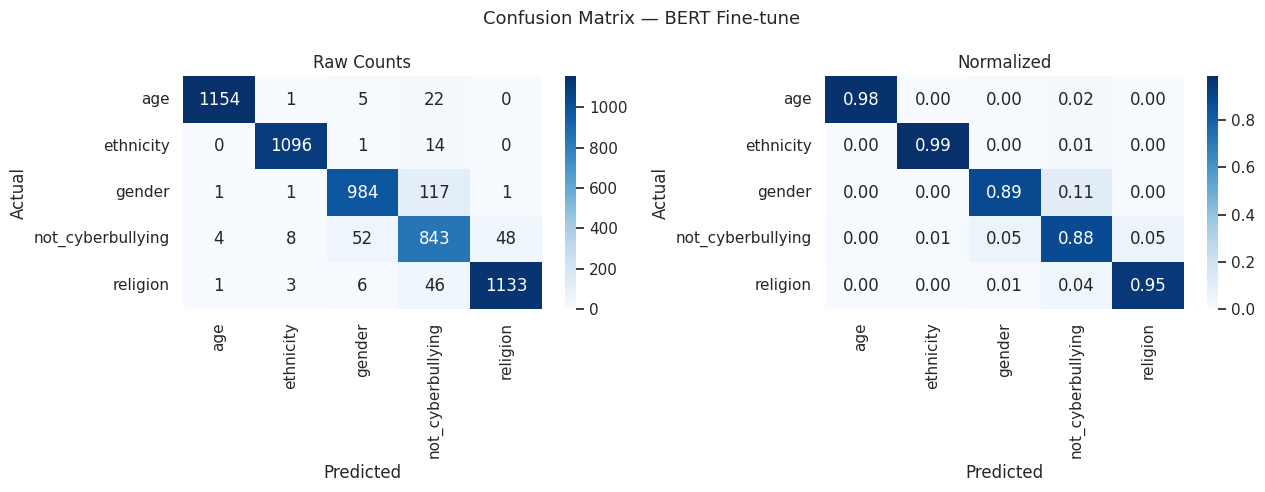

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Transformer model saved.


In [ ]:
# ── 10.5 Evaluate Transformer ─────────────────────────────────────────────────
trf_val_output  = trainer.predict(trf_ds_val)
trf_test_output = trainer.predict(trf_ds_test)

trf_val_preds  = np.argmax(trf_val_output.predictions,  axis=1)
trf_test_preds = np.argmax(trf_test_output.predictions, axis=1)

evaluate_clf("BERT Fine-tune", y_val,  trf_val_preds,  label_encoder=le, split="val")
evaluate_clf("BERT Fine-tune", y_test, trf_test_preds, label_encoder=le)
plot_confusion_matrix_clf(y_test, trf_test_preds, "BERT Fine-tune", le)

# Save fine-tuned model & tokenizer
trainer.save_model(str(CFG["model_dir"] / "transformer_best"))
trf_tokenizer.save_pretrained(str(CFG["model_dir"] / "transformer_best"))
print("Transformer model saved.")

# Section 17: Results

In [ ]:
print_results_table()


Model                                              accuracy      f1_macro   f1_weighted
Majority Baseline | test                             0.2133        0.0703        0.0750
TF-IDF + LogReg | val                                0.9240        0.9207        0.9248
TF-IDF + LogReg | test                               0.9284        0.9246        0.9288
TF-IDF + XGBoost (GPU) | val                         0.9284        0.9260        0.9302
TF-IDF + XGBoost (GPU) | test                        0.9320        0.9293        0.9334
GloVe MLP | test                                     0.8950        0.8875        0.8936
GloVe BiLSTM + Att | test                            0.9058        0.8987        0.9042
GloVe CNN | test                                     0.9013        0.8917        0.8980
GloVe BiLSTM | test                                  0.9058        0.8987        0.9042
BERT Fine-tune | val                                 0.9338        0.9312        0.9349
BERT Fine-tune | test          

In [ ]:
# ── 11.2 Results as DataFrame ─────────────────────────────────────────────────
df_results = (
    pd.DataFrame(RESULTS)
    .T
    .rename_axis("Model | Split")
    .sort_values("f1_macro", ascending=False)
)
display(df_results.round(4))

df_results.to_csv(CFG["output_dir"] / f"results_{CFG['task']}.csv")
print("Results saved.")

,accuracy,f1_macro,f1_weighted
Model | Split,,,
BERT Fine-tune | test,0.9403,0.9375,0.9410
BERT Fine-tune | val,0.9338,0.9312,0.9349
TF-IDF + XGBoost (GPU) | test,0.9320,0.9293,0.9334
TF-IDF + XGBoost (GPU) | val,0.9284,0.9260,0.9302
TF-IDF + LogReg | test,0.9284,0.9246,0.9288
TF-IDF + LogReg | val,0.9240,0.9207,0.9248
GloVe BiLSTM | test,0.9058,0.8987,0.9042
GloVe BiLSTM + Att | test,0.9058,0.8987,0.9042
GloVe CNN | test,0.9013,0.8917,0.8980


Results saved.


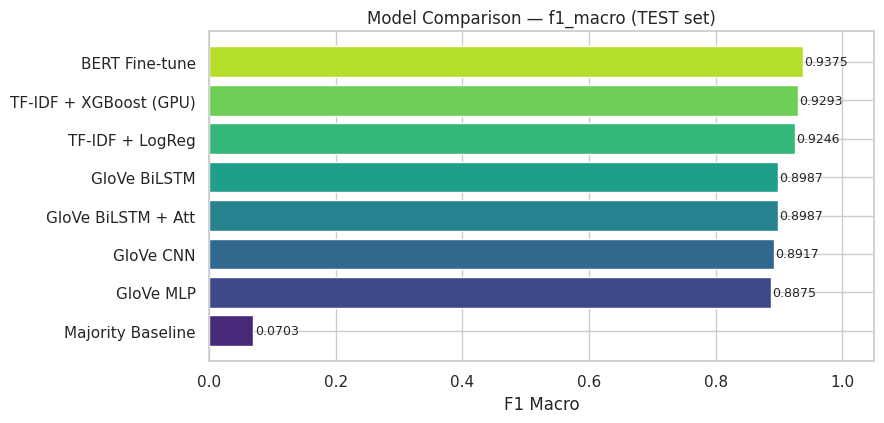

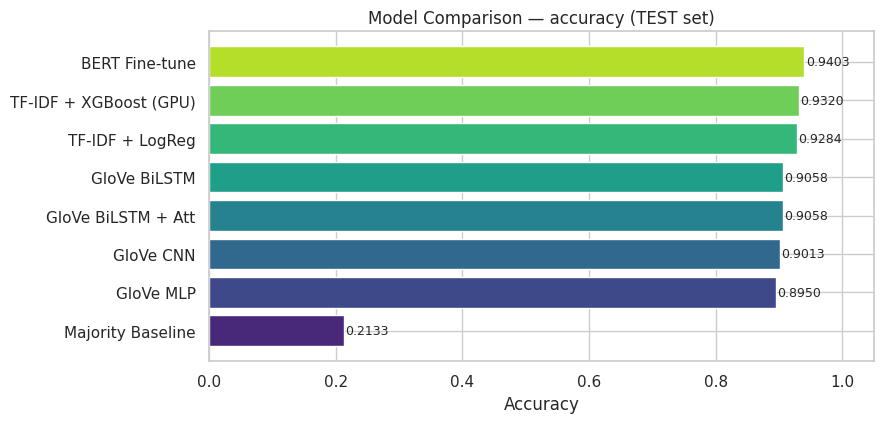

In [ ]:
# ── 11.3 Bar Chart Comparison ─────────────────────────────────────────────────
plot_model_comparison(RESULTS, metric="f1_macro", split="test")
plot_model_comparison(RESULTS, metric="accuracy", split="test")

In [ ]:
# ── 11.4 Error Analysis — Top Misclassified Samples ──────────────────────────
print("=== Error Analysis — BERT Fine-tune ===")
display(error_analysis(df_test, y_test, trf_test_preds, le, n=10))

=== Error Analysis — BERT Fine-tune ===


,tweet_text,true_label,pred_label
5,@NewEraJihadi @ShamiAnalyst You seem to have a...,not_cyberbullying,religion
26,"RT @harikondabolu: In his #Ferguson testimony,...",religion,gender
35,@TheRealFattLaff It's even more annoying that ...,not_cyberbullying,ethnicity
51,"If Jill Biden came out and said, ""Schools shou...",age,not_cyberbullying
60,After watching the Shia militia beat a Peshmer...,religion,not_cyberbullying
66,@kimberly_abraha @tom_dodsworth @pinkdevil_131...,not_cyberbullying,gender
70,@calcetin13 @boxedariel First hand account fr...,gender,not_cyberbullying
92,I'm still bad at flirting with ladies. My game...,gender,not_cyberbullying
93,"@S_Elhussieny you, yes you, are the one who pl...",gender,not_cyberbullying
105,@Ammaawah @jm111t So you are not insulted when...,not_cyberbullying,religion


In [ ]:
# ── 12.1 Save All Artefacts ───────────────────────────────────────────────────
save_artefacts()

Artefacts saved  ->  outputs/metrics  |  models/shared


In [ ]:


device = trainer.args.device
model = trainer.model
model.eval()

test_loader = DataLoader(trf_ds_test, batch_size=32, shuffle=False)

bert_embeddings_list = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_embeddings = outputs.last_hidden_state[:, 0, :]  # CLS token
        bert_embeddings_list.append(cls_embeddings.cpu().numpy())

bert_embeddings = np.vstack(bert_embeddings_list)

print("Fine-tuned BERT embeddings shape:", bert_embeddings.shape)

Fine-tuned BERT embeddings shape: (5541, 768)


In [ ]:
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

sbert_embeddings = sbert_model.encode(
    list(X_test_raw),
    show_progress_bar=True
)

print("SBERT embeddings shape:", sbert_embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/174 [00:00<?, ?it/s]

SBERT embeddings shape: (5541, 384)


In [ ]:
import umap

umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=42
)

sbert_2d = umap_model.fit_transform(sbert_embeddings)
bert_2d  = umap_model.fit_transform(bert_embeddings)

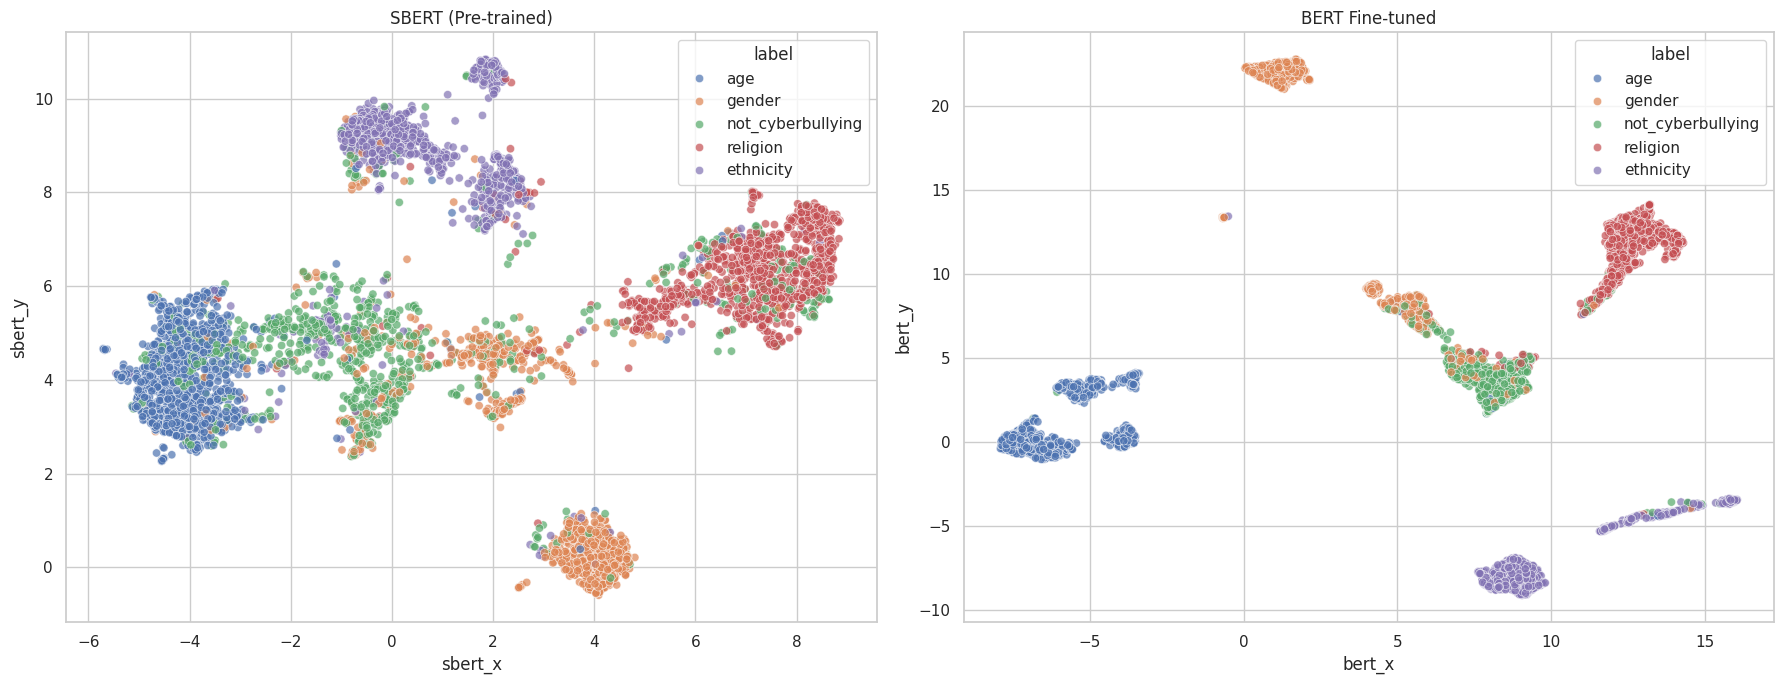

In [ ]:


df_plot = pd.DataFrame({
    "sbert_x": sbert_2d[:, 0],
    "sbert_y": sbert_2d[:, 1],
    "bert_x":  bert_2d[:, 0],
    "bert_y":  bert_2d[:, 1],
    "label": le.inverse_transform(y_test)
})

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.scatterplot(
    x="sbert_x", y="sbert_y",
    hue="label",
    data=df_plot,
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title("SBERT (Pre-trained)")

sns.scatterplot(
    x="bert_x", y="bert_y",
    hue="label",
    data=df_plot,
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title("BERT Fine-tuned")

plt.tight_layout()
plt.show()

In [ ]:
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
emb_sbert = sbert_model.encode(X_test_raw, show_progress_bar=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/174 [00:00<?, ?it/s]

In [ ]:


bert_model = AutoModel.from_pretrained(str(CFG["model_dir"] / "transformer_best"))
bert_model.eval()
bert_model.to("cuda")
emb_bert_ft = get_bert_embeddings(X_test_raw, trf_tokenizer, bert_model, CFG["max_len"])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: models/transformer_best
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:

sil_sbert = silhouette_score(emb_sbert, y_test)
db_sbert  = davies_bouldin_score(emb_sbert, y_test)

sil_bert_ft = silhouette_score(emb_bert_ft, y_test)
db_bert_ft  = davies_bouldin_score(emb_bert_ft, y_test)

print(f"SBERT pre-trained: Silhouette={sil_sbert:.3f}, Davies-Bouldin={db_sbert:.3f}")
print(f"BERT fine-tuned : Silhouette={sil_bert_ft:.3f}, Davies-Bouldin={db_bert_ft:.3f}")

SBERT pre-trained: Silhouette=0.062, Davies-Bouldin=4.333
BERT fine-tuned : Silhouette=0.635, Davies-Bouldin=0.708


In [ ]:



topic_ids = set(topics) - {-1}
# Use BERTopic's internal topic embeddings directly for consistency
topic_embeddings_dict = {topic_id: topic_model.topic_embeddings_[topic_id] for topic_id in topic_ids}

# Convert to numpy array for cosine_similarity
topic_keys = list(topic_embeddings_dict.keys())
emb_matrix = np.array([topic_embeddings_dict[t] for t in topic_keys])

In [ ]:
sim_matrix = cosine_similarity(emb_matrix)

threshold = 0.5
edges = []
for i in range(len(topic_keys)):
    for j in range(i+1, len(topic_keys)):
        if sim_matrix[i, j] >= threshold:
            edges.append((topic_keys[i], topic_keys[j], sim_matrix[i, j]))

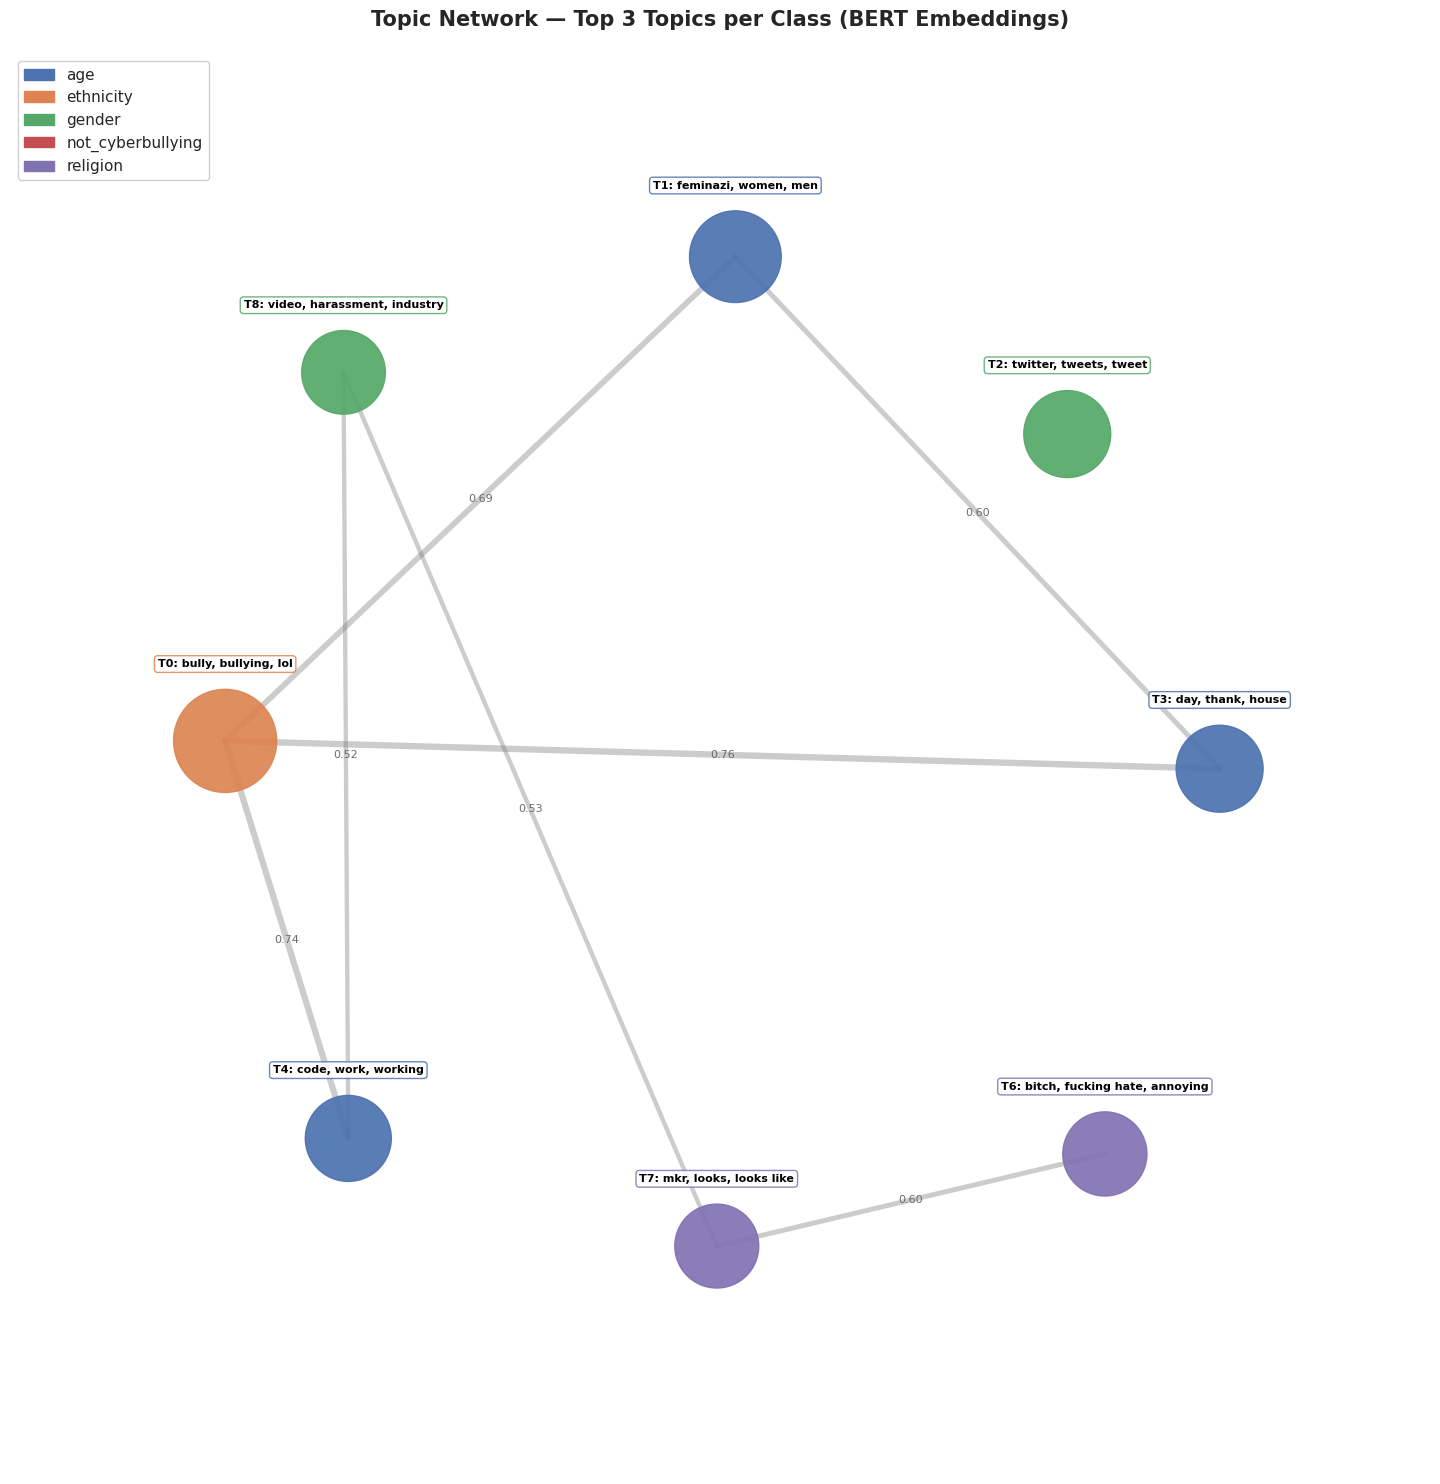

In [ ]:


class_names = le.classes_.tolist()
class_colors = {cls: _plots.COLORS[i] for i, cls in enumerate(class_names)}


topic_freq = topic_model.get_topic_info()
topic_freq = topic_freq.set_index("Topic").loc[sorted(topic_freq.Topic.unique()), :]
sizes = topic_freq['Count'].tolist()  # dimensione topic

df_plot_temp = pd.DataFrame({
    'label': le.inverse_transform(y_test[:len(new_topics)])
})

doc_topics = pd.DataFrame({
    'document': df_other['clean_text'].reset_index(drop=True),
    'topic': new_topics,
    'label': df_plot_temp['label']
})


topic_dominant_class = doc_topics.groupby('topic')['label'] \
    .agg(lambda x: x.mode()[0] if not x.mode().empty else None) \
    .to_dict()
if -1 in topic_dominant_class:
    del topic_dominant_class[-1]


top_nodes = {}
for cls in class_names:
    cls_topics = [(t, sizes[topics.index(t)])
                  for t, c in topic_dominant_class.items()
                  if c == cls and t in topics]
    cls_topics_sorted = sorted(cls_topics, key=lambda x: x[1], reverse=True)[:3]
    top_nodes[cls] = [t for t, _ in cls_topics_sorted]

selected_topics = [(t, cls) for cls, ts in top_nodes.items() for t in ts]
selected_idxs   = [topics.index(t) for t, _ in selected_topics]


embeddings_array = np.array(topic_model.topic_embeddings_)
selected_embeddings = embeddings_array[selected_idxs]
sim_matrix_sel  = cosine_similarity(selected_embeddings)

G = nx.Graph()
for t, cls in selected_topics:
    top_words = topic_model.get_topic(t)
    top_words_str = ", ".join([w for w, _ in top_words[:3]])
    G.add_node(t, cls=cls, size=sizes[topics.index(t)], label=f"T{t}: {top_words_str}")

K = 2
n = len(selected_topics)
for i in range(n):
    top_k = np.argsort(sim_matrix_sel[i])[::-1][1:K+1]
    for j in top_k:
        if j > i:
            t_i = selected_topics[i][0]
            t_j = selected_topics[j][0]
            G.add_edge(t_i, t_j, weight=float(sim_matrix_sel[i, j]))


pos = nx.spring_layout(G, k=4, seed=42)


fig, ax = plt.subplots(figsize=(20, 15))


for u, v, data in G.edges(data=True):
    x = [pos[u][0], pos[v][0]]
    y = [pos[u][1], pos[v][1]]
    ax.plot(x, y, color='gray', alpha=0.4, linewidth=data['weight'] * 6, zorder=1)

    mx, my = (pos[u][0]+pos[v][0])/2, (pos[u][1]+pos[v][1])/2
    ax.text(mx, my, f"{data['weight']:.2f}", fontsize=8, ha='center',
            va='center', color='dimgray', zorder=3)


node_radius = 0.08
for t, cls in selected_topics:
    x, y = pos[t]
    color = class_colors[cls]
    size  = G.nodes[t]['size']
    label = G.nodes[t]['label']


    circle = plt.Circle((x, y), node_radius + size/80000,
                        color=color, zorder=2, alpha=0.92)
    ax.add_patch(circle)

    ax.text(x, y + node_radius + size/80000 + 0.04, label,
            fontsize=8, ha='center', va='bottom',
            fontweight='bold', color='black',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=color, alpha=0.85),
            zorder=4)

# Legenda
legend_patches = [mpatches.Patch(color=color, label=cls)
                  for cls, color in class_colors.items()]
ax.legend(handles=legend_patches, loc='upper left', fontsize=11, framealpha=0.9)


ax.set_title("Topic Network — Top 3 Topics per Class (BERT Embeddings)",
             fontsize=15, fontweight='bold', pad=20)
ax.set_aspect('equal')
ax.axis('off')
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
plt.tight_layout()


img_path = OUTPUT_DIR / "topic_network_top3.png"
plt.savefig(str(img_path), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()